# CMP7239 - Applied Machine Learning: DDoS Attack Detection using ML & DL
## CIC-DDoS2019 Dataset Analysis

This notebook implements six machine learning and deep learning techniques
for multi-class DDoS attack classification using the CIC-DDoS2019 dataset.
- **ML Models:** Random Forest, XGBoost, Decision Tree, KNN
- **DL Models:** ANN (Deep MLP), 1D-CNN

**Dataset Source:** [CIC-DDoS2019 Dataset on Kaggle](https://www.kaggle.com/datasets/dhoogla/cicddos2019)  
**Original Source:** [University of New Brunswick - CIC](https://www.unb.ca/cic/datasets/ddos-2019.html)

### Proposed Innovation
This project introduces a **Hybrid Loss Function** combining Mean Squared Error (MSE) and
Categorical Cross-Entropy (CE) for deep learning models:  
**Loss = α · MSE + (1 − α) · CE**, where α is a tuneable weighting parameter.  
This dual-objective training encourages both probabilistic calibration and regression-style
error minimisation, improving generalisation on imbalanced multi-class DDoS detection tasks.


---
## 1. Import Libraries and Setup

In [ ]:
# Install required packages
!pip install xgboost -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
import gc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, auc)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight

# Manual oversampling for handling class imbalance (ML Improvement Strategy)
from sklearn.utils import resample

# XGBoost
from xgboost import XGBClassifier

# Deep Learning - TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Conv1D, MaxPooling1D, Flatten,
                                      BatchNormalization, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

2026-03-18 18:34:46.548702: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773858886.770351      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773858886.826240      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773858887.335978      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773858887.336016      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773858887.336019      55 computation_placer.cc:177] computation placer alr

All libraries imported successfully!
TensorFlow version: 2.19.0


---
## 2. Data Loading and Initial Exploration

The CIC-DDoS2019 dataset contains 88 features extracted using CICFlowMeter-V3.
Due to the large size (30GB), we will load and sample from multiple CSV files
to create a balanced, representative dataset.

In [ ]:
# List all available CSV files
input_dir = '/kaggle/input'
all_files = []
for dirname, _, filenames in os.walk(input_dir):
    for filename in filenames:
        if filename.endswith('.csv'):
            filepath = os.path.join(dirname, filename)
            all_files.append(filepath)
            print(f"Found: {filepath}")

print(f"\nTotal CSV files found: {len(all_files)}")

Found: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/NetBIOS.csv
Found: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/UDPLag.csv
Found: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/Syn.csv
Found: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/MSSQL.csv
Found: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/Portmap.csv
Found: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/UDP.csv
Found: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/LDAP.csv
Found: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_NetBIOS.csv
Found: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/01-12/DrDoS_SSDP.csv
Found: /kaggle/input/datasets/rodrigorosasilva/cic-

In [ ]:
# Load and combine data from CSV files
# IMPORTANT: Read only sample_per_file rows directly (never load full file)
# This prevents Kaggle OOM on the 30GB dataset

dataframes = []
sample_per_file = 50000  # Rows to take per file

for file in all_files:
    try:
        # Count rows without loading full file
        total_rows = sum(1 for _ in open(file)) - 1  # subtract header

        if total_rows <= sample_per_file:
            # Small file — read entirely
            df_temp = pd.read_csv(file, low_memory=False)
        else:
            # Large file — random sample using skiprows
            # Read header first, then sample rows
            np.random.seed(42)
            skip_idx = np.random.choice(range(1, total_rows + 1),
                                        size=total_rows - sample_per_file,
                                        replace=False)
            df_temp = pd.read_csv(file, skiprows=skip_idx, low_memory=False)

        dataframes.append(df_temp)
        print(f"Loaded {file.split('/')[-1]}: {df_temp.shape[0]} rows, {df_temp.shape[1]} cols")

        # Free memory after each file
        del df_temp
        gc.collect()

    except Exception as e:
        print(f"Error loading {file.split('/')[-1]}: {e}")

# Combine all dataframes
df = pd.concat(dataframes, ignore_index=True)
print(f"\n--- Combined Dataset Shape: {df.shape} ---")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")

# Free memory
del dataframes
gc.collect()

Loaded NetBIOS.csv: 50000 rows, 88 cols
Loaded UDPLag.csv: 50000 rows, 88 cols
Loaded Syn.csv: 50000 rows, 88 cols
Loaded MSSQL.csv: 50000 rows, 88 cols
Loaded Portmap.csv: 50000 rows, 88 cols
Loaded UDP.csv: 50000 rows, 88 cols
Loaded LDAP.csv: 50000 rows, 88 cols
Loaded DrDoS_NetBIOS.csv: 50000 rows, 88 cols
Loaded DrDoS_SSDP.csv: 50000 rows, 88 cols
Loaded DrDoS_NTP.csv: 50000 rows, 88 cols
Loaded TFTP.csv: 50000 rows, 88 cols
Loaded UDPLag.csv: 50000 rows, 88 cols
Loaded DrDoS_UDP.csv: 50000 rows, 88 cols
Loaded Syn.csv: 50000 rows, 88 cols
Loaded DrDoS_MSSQL.csv: 50000 rows, 88 cols
Loaded DrDoS_SNMP.csv: 50000 rows, 88 cols
Loaded DrDoS_DNS.csv: 50000 rows, 88 cols
Loaded DrDoS_LDAP.csv: 50000 rows, 88 cols

--- Combined Dataset Shape: (900000, 88) ---
Total rows: 900,000
Total columns: 88


0

In [ ]:
# Strip whitespace from column names (common issue with CIC datasets)
df.columns = df.columns.str.strip()

# Display basic info
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nColumn Names ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col} ({df[col].dtype})")

DATASET OVERVIEW

Shape: (900000, 88)

Column Names (88):
  1. Unnamed: 0 (int64)
  2. Flow ID (object)
  3. Source IP (object)
  4. Source Port (int64)
  5. Destination IP (object)
  6. Destination Port (int64)
  7. Protocol (int64)
  8. Timestamp (object)
  9. Flow Duration (int64)
  10. Total Fwd Packets (int64)
  11. Total Backward Packets (int64)
  12. Total Length of Fwd Packets (float64)
  13. Total Length of Bwd Packets (float64)
  14. Fwd Packet Length Max (float64)
  15. Fwd Packet Length Min (float64)
  16. Fwd Packet Length Mean (float64)
  17. Fwd Packet Length Std (float64)
  18. Bwd Packet Length Max (float64)
  19. Bwd Packet Length Min (float64)
  20. Bwd Packet Length Mean (float64)
  21. Bwd Packet Length Std (float64)
  22. Flow Bytes/s (float64)
  23. Flow Packets/s (float64)
  24. Flow IAT Mean (float64)
  25. Flow IAT Std (float64)
  26. Flow IAT Max (float64)
  27. Flow IAT Min (float64)
  28. Fwd IAT Total (float64)
  29. Fwd IAT Mean (float64)
  30. Fwd IAT St

In [ ]:
# Display first few rows
print("First 5 rows:")
df.head()

First 5 rows:


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,75144,172.16.0.5-192.168.50.4-895-31543-17,172.16.0.5,895,192.168.50.4,31543,17,2018-11-03 10:01:48.924670,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
1,25815,172.16.0.5-192.168.50.4-914-22200-17,172.16.0.5,914,192.168.50.4,22200,17,2018-11-03 10:01:48.926391,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
2,252104,172.16.0.5-192.168.50.4-917-60518-17,172.16.0.5,917,192.168.50.4,60518,17,2018-11-03 10:01:48.926503,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
3,221396,172.16.0.5-192.168.50.4-981-60439-17,172.16.0.5,981,192.168.50.4,60439,17,2018-11-03 10:01:48.933640,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
4,151136,172.16.0.5-192.168.50.4-1014-1013-17,172.16.0.5,1014,192.168.50.4,1013,17,2018-11-03 10:01:48.936849,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS


In [ ]:
# Basic statistics
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df.describe()

DESCRIPTIVE STATISTICS


,Unnamed: 0,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound
count,900000.000000,900000.000000,900000.000000,900000.000000,9.000000e+05,900000.000000,900000.000000,900000.000000,9.000000e+05,900000.000000,...,9.000000e+05,9.000000e+05,9.000000e+05,9.000000e+05,9.000000e+05,9.000000e+05,9.000000e+05,9.000000e+05,9.000000e+05,900000.000000
mean,115730.443418,24139.430247,32791.901479,14.711850,1.486110e+06,6.757631,0.171330,2719.026849,1.497584e+01,536.741542,...,-3.594082e+07,2.157341e+03,2.832692e+03,5.983781e+03,5.485410e+02,4.296852e+05,1.087259e+05,5.511068e+05,3.307376e+05,0.996117
std,145259.424372,24382.341169,18934.233106,4.465948,9.371824e+06,262.148861,1.861487,9096.506425,1.823685e+03,516.441564,...,1.921115e+08,6.888819e+04,7.678543e+04,1.577234e+05,4.955488e+04,2.830632e+06,9.025892e+05,3.619736e+06,2.327763e+06,0.062195
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,...,-1.408238e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,19952.000000,774.000000,16415.750000,17.000000,1.000000e+00,2.000000,0.000000,458.000000,0.000000e+00,229.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
50%,61738.000000,16081.000000,32797.000000,17.000000,1.000000e+00,2.000000,0.000000,878.000000,0.000000e+00,393.000000,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
75%,140560.250000,47866.000000,49202.250000,17.000000,5.000000e+01,2.000000,0.000000,2880.000000,0.000000e+00,559.000000,...,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
max,805239.000000,65532.000000,65535.000000,17.000000,1.199999e+08,99526.000000,692.000000,176000.000000,1.122592e+06,3617.000000,...,6.724045e+07,1.402356e+07,2.135244e+07,4.553668e+07,1.402356e+07,8.663698e+07,4.356504e+07,8.663698e+07,8.663698e+07,1.000000


---
## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Identify the label/target column
# CIC-DDoS2019 typically has ' Label' or 'Label' as the target
label_col = None
for col in df.columns:
    if 'label' in col.lower():
        label_col = col
        break

if label_col is None:
    # Try last column
    label_col = df.columns[-1]

print(f"Target column identified: '{label_col}'")
print(f"\nClass Distribution:")
class_dist = df[label_col].value_counts()
print(class_dist)
print(f"\nTotal unique classes: {df[label_col].nunique()}")

Target column identified: 'Label'

Class Distribution:
Label
Syn              141287
UDP               57484
NetBIOS           54797
MSSQL             50201
DrDoS_SNMP        49989
DrDoS_SSDP        49985
DrDoS_MSSQL       49982
DrDoS_NetBIOS     49974
DrDoS_DNS         49972
DrDoS_UDP         49963
DrDoS_LDAP        49961
TFTP              49939
UDP-lag           49433
DrDoS_NTP         49421
Portmap           48784
LDAP              45128
BENIGN             3524
UDPLag              118
WebDDoS              58
Name: count, dtype: int64

Total unique classes: 19


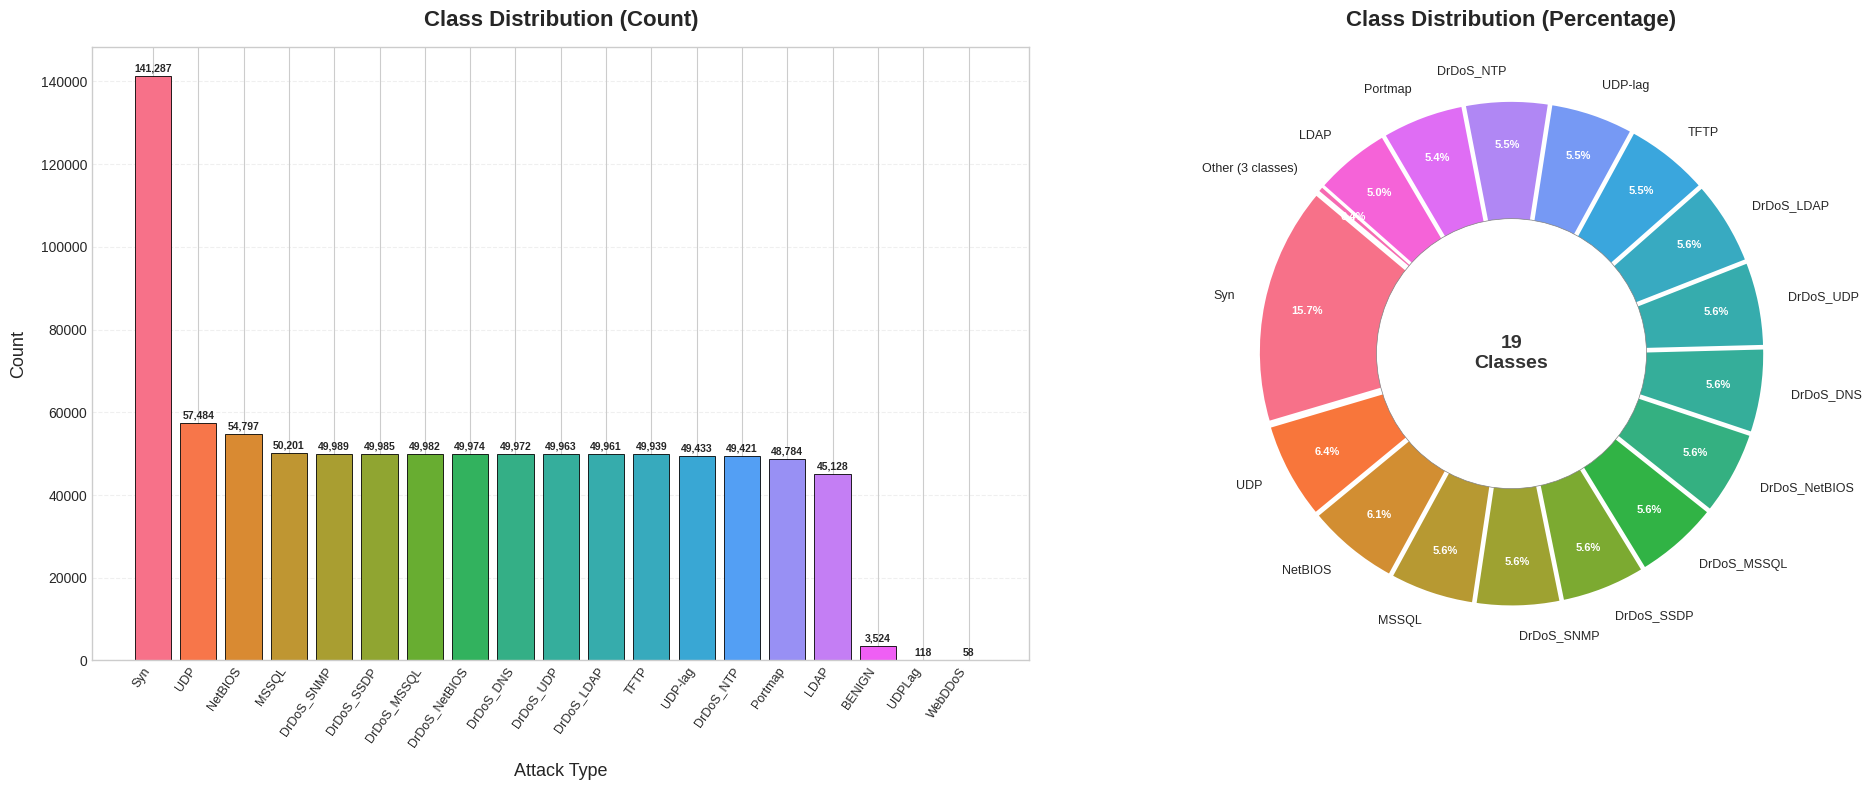

In [ ]:
# Figure 1: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Bar Chart (Left) ---
colors_bar = sns.color_palette("husl", len(class_dist))
bars = axes[0].bar(range(len(class_dist)), class_dist.values, color=colors_bar, edgecolor='black', linewidth=0.6)
axes[0].set_title('Class Distribution (Count)', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Attack Type', fontsize=13, labelpad=10)
axes[0].set_ylabel('Count', fontsize=13, labelpad=10)
axes[0].set_xticks(range(len(class_dist)))
axes[0].set_xticklabels(class_dist.index, rotation=55, ha='right', fontsize=9)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 500,
                 f'{int(height):,}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_axisbelow(True)

# --- Pie Chart (Right) - Grouped small slices ---
# Separate major and minor classes for cleaner pie chart
threshold_pct = 3.0  # Group classes below 3% into "Other"
total = class_dist.sum()
pct = (class_dist / total) * 100

major = class_dist[pct >= threshold_pct]
minor = class_dist[pct < threshold_pct]

if len(minor) > 0:
    pie_data = pd.concat([major, pd.Series({'Other (' + str(len(minor)) + ' classes)': minor.sum()})])
else:
    pie_data = major

colors_pie = sns.color_palette("husl", len(pie_data))
explode = [0.03] * len(pie_data)

wedges, texts, autotexts = axes[1].pie(
    pie_data.values,
    labels=pie_data.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=140,
    explode=explode,
    pctdistance=0.82,
    labeldistance=1.12,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Style the percentage text
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Add a center circle for donut style (cleaner look)
centre_circle = plt.Circle((0, 0), 0.55, fc='white', edgecolor='gray', linewidth=0.5)
axes[1].add_artist(centre_circle)
axes[1].text(0, 0, f'{len(class_dist)}\nClasses', ha='center', va='center',
             fontsize=14, fontweight='bold', color='#333333')

axes[1].set_title('Class Distribution (Percentage)', fontsize=16, fontweight='bold', pad=15)

plt.tight_layout(w_pad=4)
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Check for missing values and infinite values
print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(f"\nColumns with missing values: {len(missing_df)}")
if len(missing_df) > 0:
    print(missing_df.sort_values('Missing Count', ascending=False))

DATA QUALITY ASSESSMENT

Columns with missing values: 1
              Missing Count  Percentage
Flow Bytes/s          11166    1.240667


In [ ]:
# Check data types
print("\nData Types Summary:")
print(df.dtypes.value_counts())

# Identify numeric and non-numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Non-numeric columns: {len(non_numeric_cols)}")
print(f"Non-numeric: {non_numeric_cols}")


Data Types Summary:
float64    45
int64      37
object      6
Name: count, dtype: int64

Numeric columns: 82
Non-numeric columns: 6
Non-numeric: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'SimillarHTTP', 'Label']


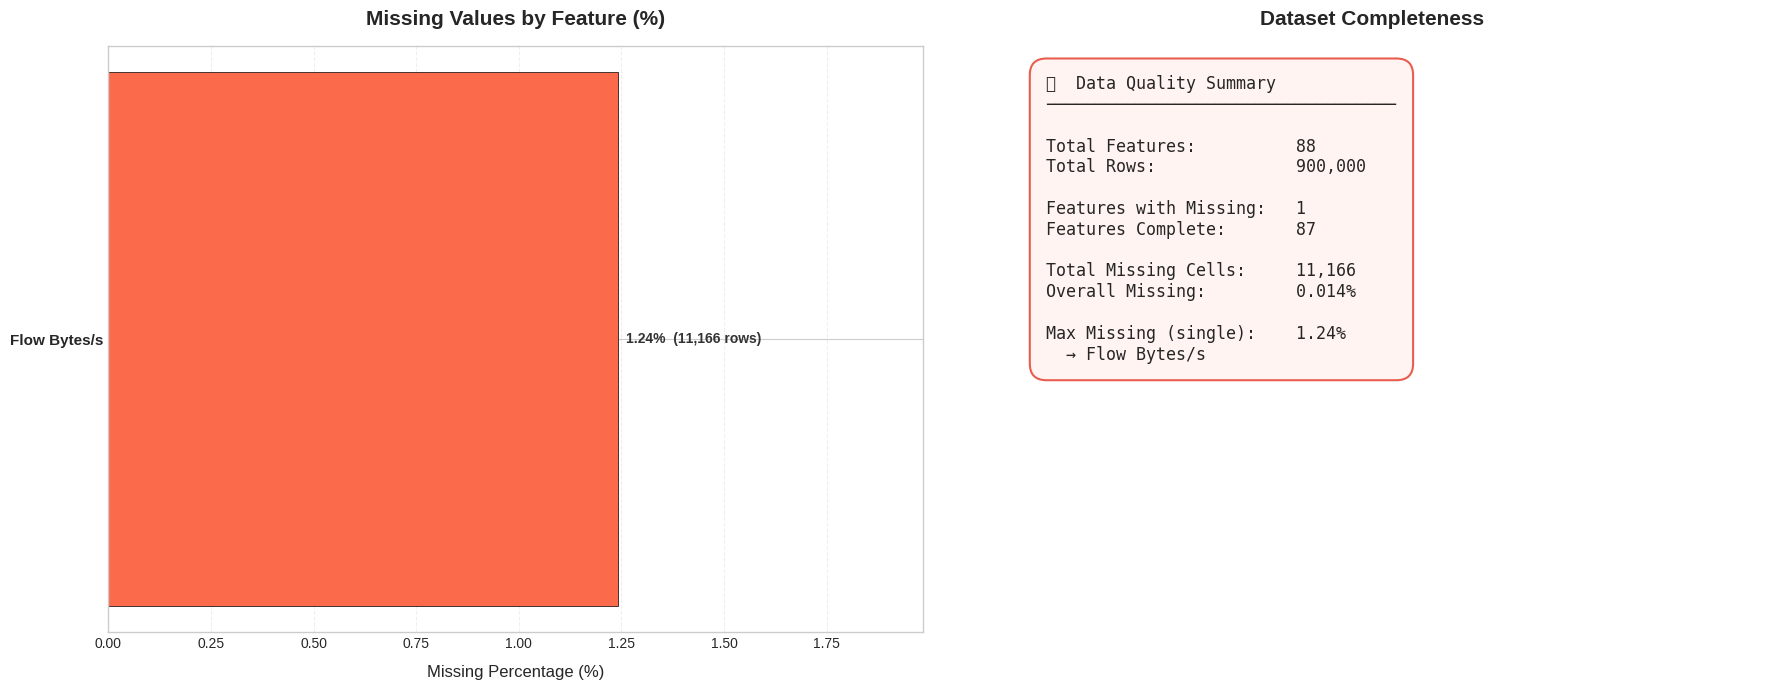

In [ ]:
# Figure 2: Missing Values Analysis
if len(missing_df) > 0:
    missing_plot = missing_df.sort_values('Percentage', ascending=False).head(20)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # --- Left: Horizontal Bar Chart (much cleaner for few columns) ---
    colors = sns.color_palette("Reds_r", len(missing_plot))
    bars = axes[0].barh(range(len(missing_plot)), missing_plot['Percentage'].values,
                        color=colors, edgecolor='black', linewidth=0.5, height=0.6)
    axes[0].set_yticks(range(len(missing_plot)))
    axes[0].set_yticklabels(missing_plot.index, fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Missing Percentage (%)', fontsize=12, labelpad=10)
    axes[0].set_title('Missing Values by Feature (%)', fontsize=15, fontweight='bold', pad=15)
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3, linestyle='--')
    axes[0].set_axisbelow(True)

    # Add percentage labels on bars
    for bar, pct, count in zip(bars, missing_plot['Percentage'].values, missing_plot['Missing Count'].values):
        axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2.,
                     f'{pct:.2f}%  ({int(count):,} rows)',
                     ha='left', va='center', fontsize=10, fontweight='bold', color='#333333')

    # Extend x-axis to fit labels
    axes[0].set_xlim(0, missing_plot['Percentage'].max() * 1.6)

    # --- Right: Summary Info Box ---
    axes[1].axis('off')

    total_cells = df.shape[0] * df.shape[1]
    total_missing = missing_df['Missing Count'].sum()
    cols_with_missing = len(missing_df)
    overall_pct = (total_missing / total_cells) * 100

    summary_text = (
        f"📊  Data Quality Summary\n"
        f"{'─' * 35}\n\n"
        f"Total Features:          {df.shape[1]}\n"
        f"Total Rows:              {df.shape[0]:,}\n\n"
        f"Features with Missing:   {cols_with_missing}\n"
        f"Features Complete:       {df.shape[1] - cols_with_missing}\n\n"
        f"Total Missing Cells:     {int(total_missing):,}\n"
        f"Overall Missing:         {overall_pct:.3f}%\n\n"
        f"Max Missing (single):    {missing_plot['Percentage'].max():.2f}%\n"
        f"  → {missing_plot.index[0]}"
    )

    axes[1].text(0.1, 0.95, summary_text, transform=axes[1].transAxes,
                 fontsize=12, verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle='round,pad=1', facecolor='#FFF3F0',
                          edgecolor='#E74C3C', alpha=0.9, linewidth=1.5))

    axes[1].set_title('Dataset Completeness', fontsize=15, fontweight='bold', pad=15)

    plt.tight_layout(w_pad=3)
    plt.savefig('fig2_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("✓ No missing values found - dataset is clean!")

---
## 4. Data Preprocessing

In [ ]:
# Step 1: Remove non-numeric identifiers (Timestamp, Source IP, Dest IP, Flow ID, etc.)
cols_to_drop = []
for col in df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in ['timestamp', 'flow id', 'source ip', 'destination ip',
                                                  'src ip', 'dst ip', 'source port', 'destination port',
                                                  'src port', 'dst port', 'unnamed', 'flow_id',
                                                  'source_ip', 'destination_ip']):
        cols_to_drop.append(col)

# Keep label column even if it matches
cols_to_drop = [c for c in cols_to_drop if c != label_col]

print(f"Columns to drop (identifiers): {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Shape after dropping identifiers: {df.shape}")

Columns to drop (identifiers): ['Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp']
Shape after dropping identifiers: (900000, 81)


In [ ]:
# Step 2: Handle infinite values
print("Handling infinite values...")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    inf_count = np.isinf(df[col]).sum()
    if inf_count > 0:
        print(f"  {col}: {inf_count} infinite values replaced")
        df[col].replace([np.inf, -np.inf], np.nan, inplace=True)

Handling infinite values...
  Flow Bytes/s: 23856 infinite values replaced
  Flow Packets/s: 35022 infinite values replaced


In [ ]:
# Step 3: Handle missing values (after replacing inf)
print("\nHandling missing values...")
missing_after = df.isnull().sum().sum()
print(f"Total missing values: {missing_after}")

# Drop columns with >50% missing
threshold = 0.5
cols_before = len(df.columns)
df.dropna(axis=1, thresh=int((1 - threshold) * len(df)), inplace=True)
print(f"Columns dropped (>{threshold*100}% missing): {cols_before - len(df.columns)}")

# Fill remaining missing values with median for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Drop rows with any remaining NaN
df.dropna(inplace=True)
print(f"Shape after handling missing values: {df.shape}")


Handling missing values...
Total missing values: 70044
Columns dropped (>50.0% missing): 0
Shape after handling missing values: (900000, 81)


In [ ]:
# Step 4: Remove duplicate rows
before_dup = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before_dup - len(df)}")
print(f"Shape after deduplication: {df.shape}")

Duplicates removed: 663995
Shape after deduplication: (236005, 81)


In [ ]:
# Step 5: Encode the target variable
le = LabelEncoder()
df['Label_Encoded'] = le.fit_transform(df[label_col])

print(f"Label Encoding Mapping:")
for i, cls in enumerate(le.classes_):
    count = (df['Label_Encoded'] == i).sum()
    print(f"  {i}: {cls} ({count:,} samples)")

num_classes = len(le.classes_)
print(f"\nTotal classes: {num_classes}")

Label Encoding Mapping:
  0: BENIGN (3,375 samples)
  1: DrDoS_DNS (5,531 samples)
  2: DrDoS_LDAP (3,332 samples)
  3: DrDoS_MSSQL (12,827 samples)
  4: DrDoS_NTP (46,695 samples)
  5: DrDoS_NetBIOS (1,336 samples)
  6: DrDoS_SNMP (6,152 samples)
  7: DrDoS_SSDP (25,302 samples)
  8: DrDoS_UDP (25,497 samples)
  9: LDAP (2,238 samples)
  10: MSSQL (14,290 samples)
  11: NetBIOS (895 samples)
  12: Portmap (821 samples)
  13: Syn (20,003 samples)
  14: TFTP (24,884 samples)
  15: UDP (29,654 samples)
  16: UDP-lag (13,043 samples)
  17: UDPLag (72 samples)
  18: WebDDoS (58 samples)

Total classes: 19


In [ ]:
# Step 6: Separate features and target
X = df.drop(columns=[label_col, 'Label_Encoded'])

# Ensure all features are numeric
X = X.select_dtypes(include=[np.number])
y = df['Label_Encoded']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nNumber of features: {X.shape[1]}")

# Verify >= 50 features requirement
assert X.shape[1] >= 50, f"Only {X.shape[1]} features! Need at least 50."
print(f"✓ Feature count requirement met: {X.shape[1]} >= 50")

# Verify >= 5000 rows requirement
assert X.shape[0] >= 50000, f"Only {X.shape[0]} rows! Need at least 50000."
print(f"✓ Row count requirement met: {X.shape[0]:,} >= 50,000")

Feature matrix shape: (236005, 79)
Target vector shape: (236005,)

Number of features: 79
✓ Feature count requirement met: 79 >= 50
✓ Row count requirement met: 236,005 >= 50,000


Total features available: 79
Displaying correlation heatmap for top 50 features (by variance)


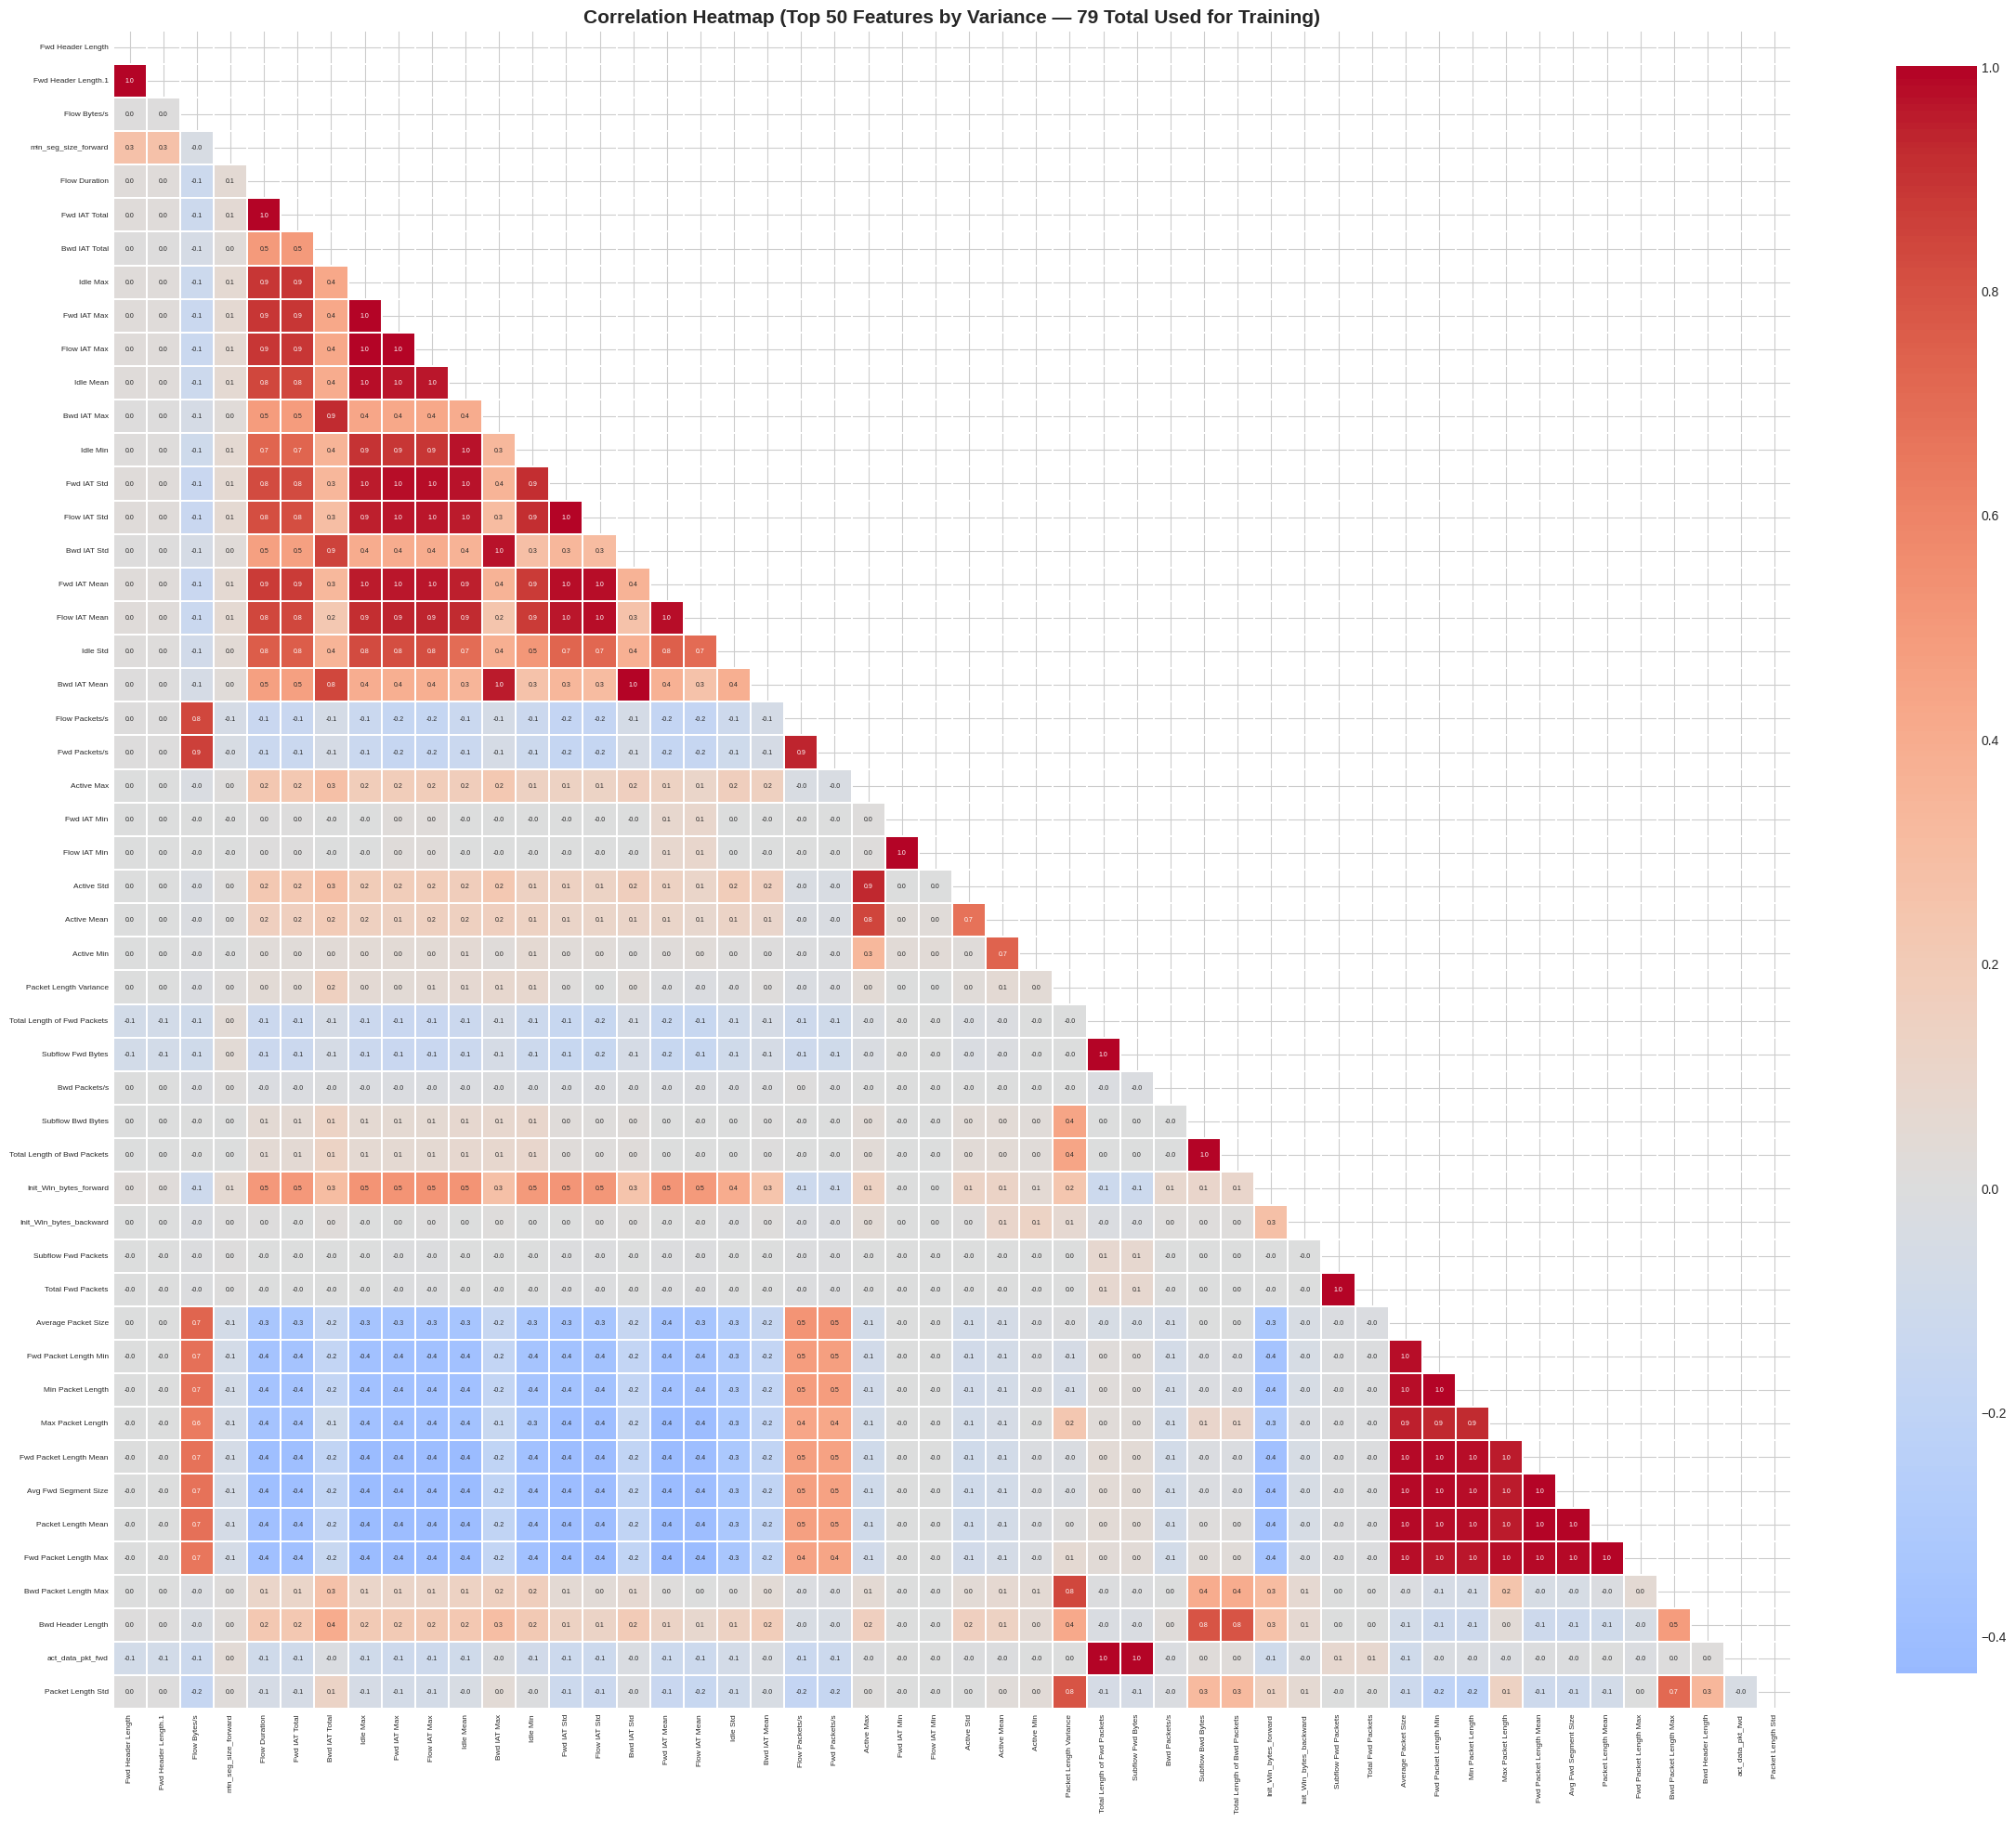

In [ ]:
# Figure 3: Correlation Heatmap — Using ALL features
# Select top 50 features by variance for a readable heatmap
print(f"Total features available: {X.shape[1]}")

# Pick top 50 features by variance
top_50_features = X.var().sort_values(ascending=False).head(50).index.tolist()
print(f"Displaying correlation heatmap for top 50 features (by variance)")

fig, ax = plt.subplots(figsize=(24, 22))
corr_matrix = X[top_50_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.1f', cmap='coolwarm',
            center=0, square=True, linewidths=0.3, ax=ax, annot_kws={"size": 5},
            cbar_kws={"shrink": 0.8})
ax.set_title(f'Correlation Heatmap (Top 50 Features by Variance — {X.shape[1]} Total Used for Training)',
             fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=6)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

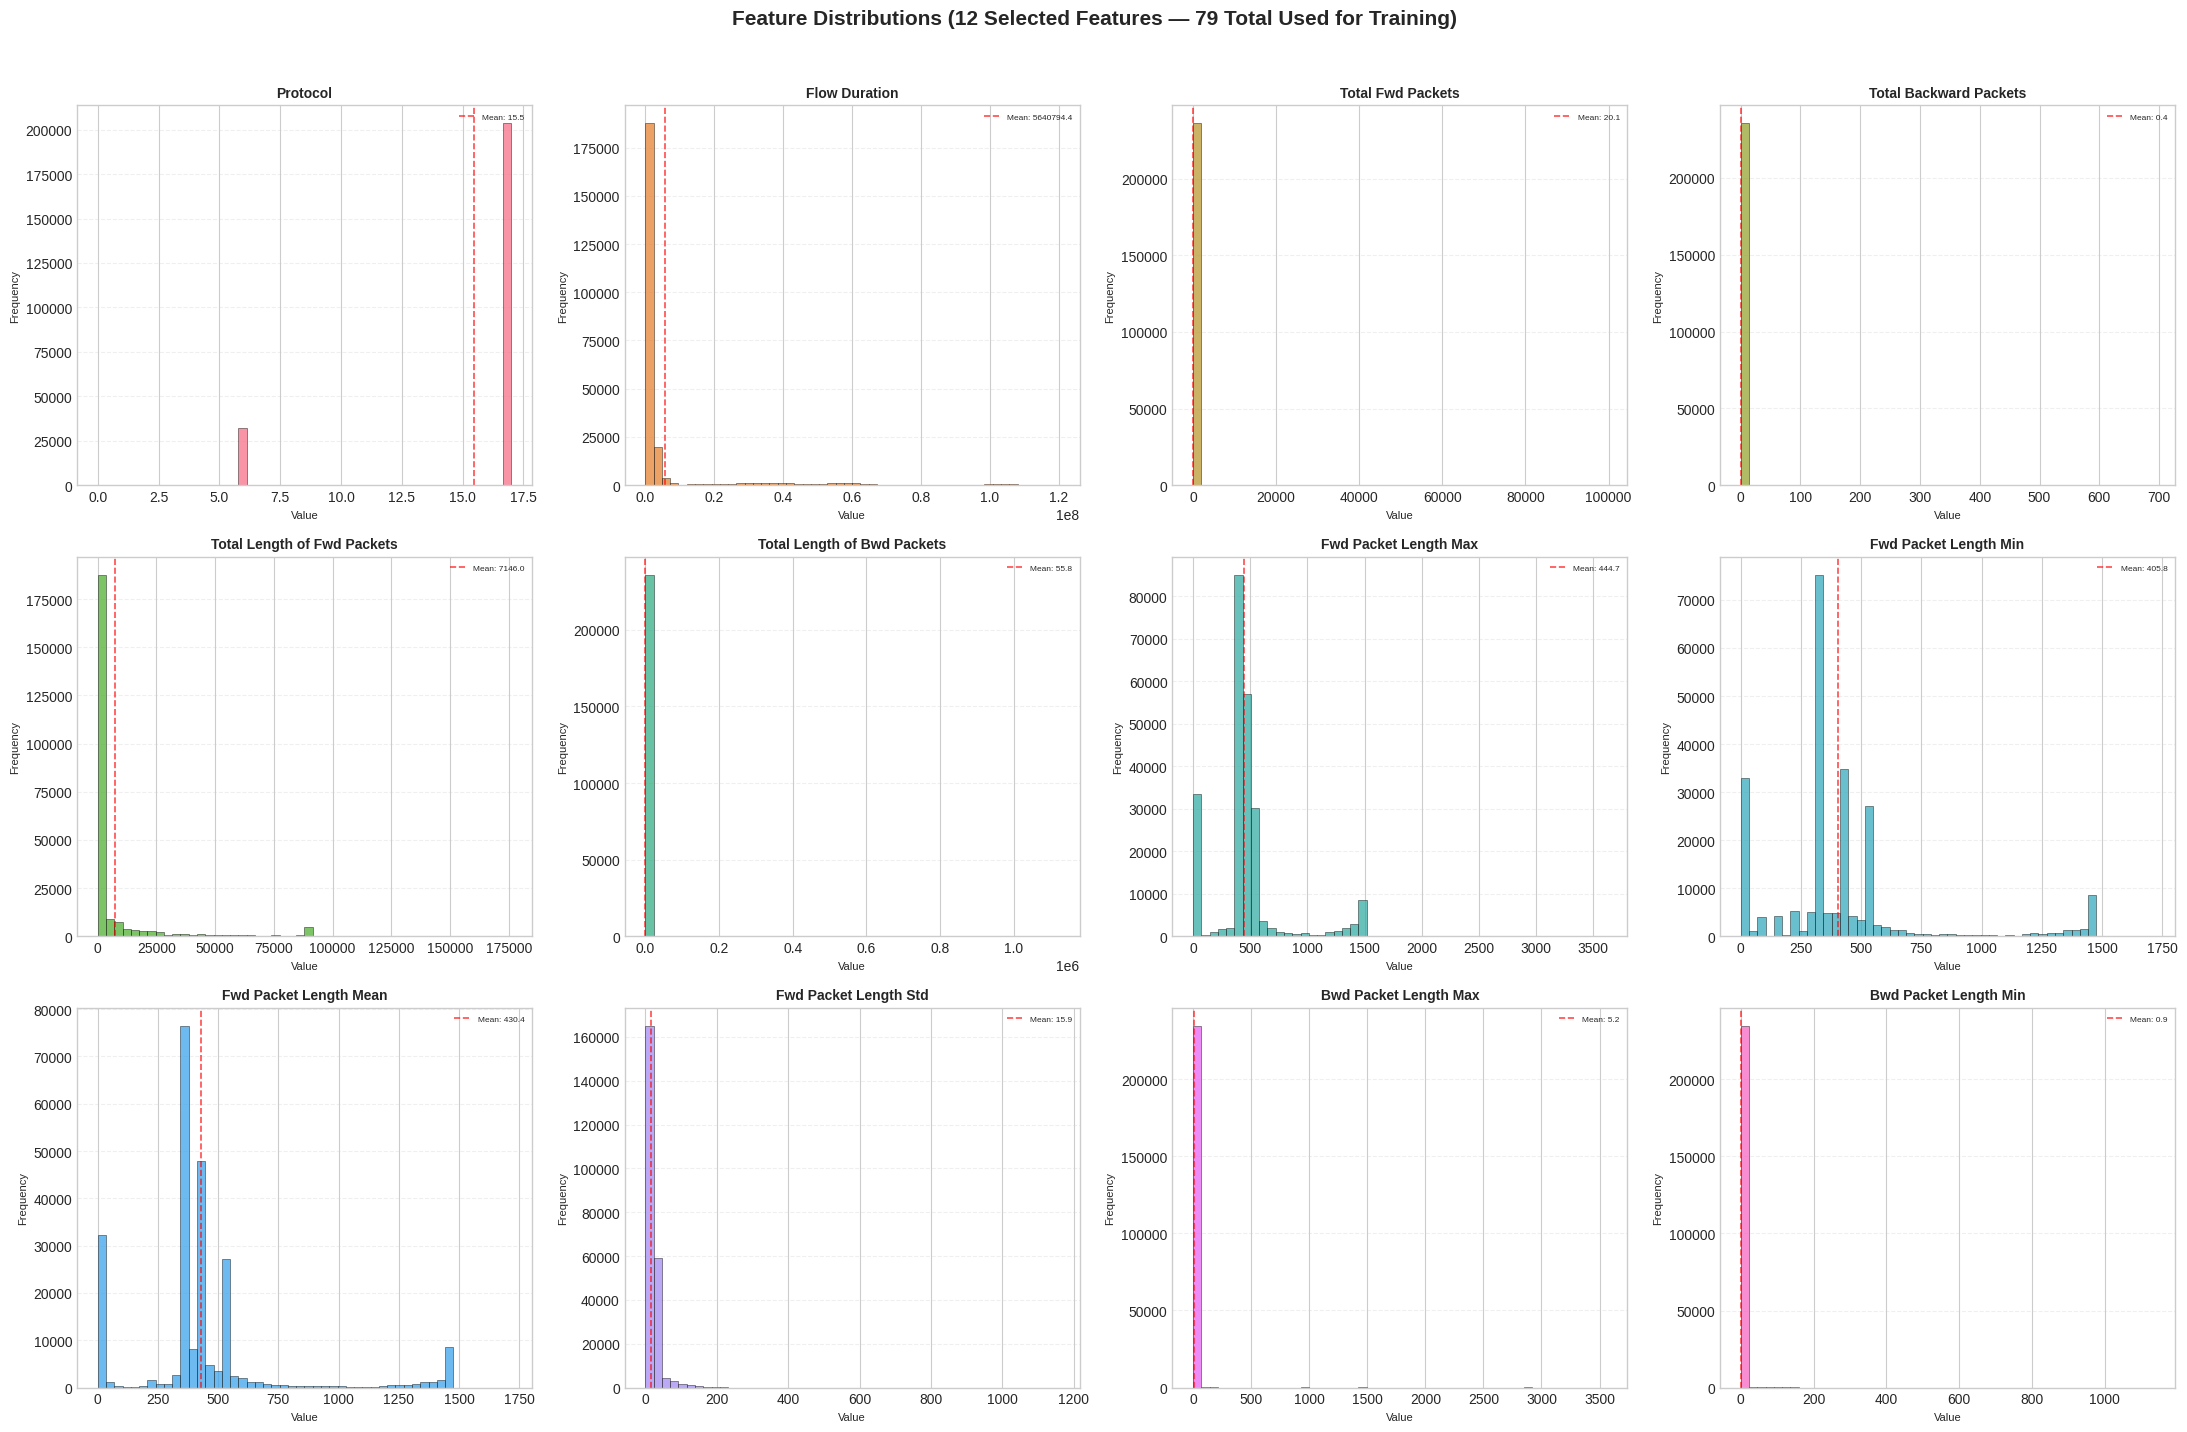

In [ ]:
# Figure 4: Feature Distribution (selected features)
# Select only numeric features that have variance
numeric_features = X.select_dtypes(include=[np.number]).columns
valid_features = [col for col in numeric_features if X[col].std() > 0][:12]

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

colors = sns.color_palette("husl", len(valid_features))

for i, feat in enumerate(valid_features):
    axes[i].hist(X[feat], bins=50, alpha=0.75, color=colors[i], edgecolor='black', linewidth=0.4)
    axes[i].set_title(f'{feat}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Frequency', fontsize=8)
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    axes[i].set_axisbelow(True)

    # Add mean line
    mean_val = X[feat].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=6, loc='upper right')

# Hide any unused subplots
for j in range(len(valid_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Feature Distributions (12 Selected Features — {X.shape[1]} Total Used for Training)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Step 7: Feature Scaling using StandardScaler

# Clean remaining inf and extremely large values
print("Cleaning remaining infinite and extreme values...")
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Cap extreme values at 99.9th percentile per column
for col in X.columns:
    upper = X[col].quantile(0.999)
    lower = X[col].quantile(0.001)
    X[col] = X[col].clip(lower=lower, upper=upper)

# Fill any NaN created from inf replacement
X.fillna(X.median(), inplace=True)

# Verify no inf or NaN remain
print(f"Infinite values remaining: {np.isinf(X.values).sum()}")
print(f"NaN values remaining:      {np.isnan(X.values).sum()}")

# Now scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print("Feature scaling applied (StandardScaler - zero mean, unit variance)")
print(f"Scaled features - Mean: {X_scaled.mean().mean():.6f}, Std: {X_scaled.std().mean():.6f}")

Cleaning remaining infinite and extreme values...
Infinite values remaining: 0
NaN values remaining:      0
Feature scaling applied (StandardScaler - zero mean, unit variance)
Scaled features - Mean: -0.000000, Std: 0.835445


In [ ]:
# Step 8: Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Testing set:  {X_test.shape[0]:,} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training set: 188,804 samples
Testing set:  47,201 samples

Training class distribution:
Label_Encoded
0      2700
1      4425
2      2666
3     10262
4     37356
5      1069
6      4922
7     20241
8     20398
9      1790
10    11432
11      716
12      657
13    16002
14    19907
15    23723
16    10434
17       58
18       46
Name: count, dtype: int64

Testing class distribution:
Label_Encoded
0      675
1     1106
2      666
3     2565
4     9339
5      267
6     1230
7     5061
8     5099
9      448
10    2858
11     179
12     164
13    4001
14    4977
15    5931
16    2609
17      14
18      12
Name: count, dtype: int64


---
## 5. Feature Importance Analysis

Computing feature importance using Random Forest...

Top 50 Most Important Features (out of 79 total):
                    Feature  Importance
       Avg Fwd Segment Size    0.063598
      Fwd Packet Length Max    0.055515
Total Length of Fwd Packets    0.051739
         Packet Length Mean    0.049488
                Fwd IAT Std    0.047458
          Max Packet Length    0.045013
        Average Packet Size    0.043117
          Total Fwd Packets    0.042921
               Flow Bytes/s    0.040010
          Subflow Fwd Bytes    0.039881
     Fwd Packet Length Mean    0.039049
        Subflow Fwd Packets    0.037074
          Min Packet Length    0.035876
           act_data_pkt_fwd    0.035336
      Fwd Packet Length Min    0.033880
               Fwd IAT Mean    0.032797
              Flow Duration    0.032356
                Fwd IAT Max    0.025088
              Fwd IAT Total    0.022716
             Flow Packets/s    0.022002
               Flow IAT Std    0.019910
              Flo

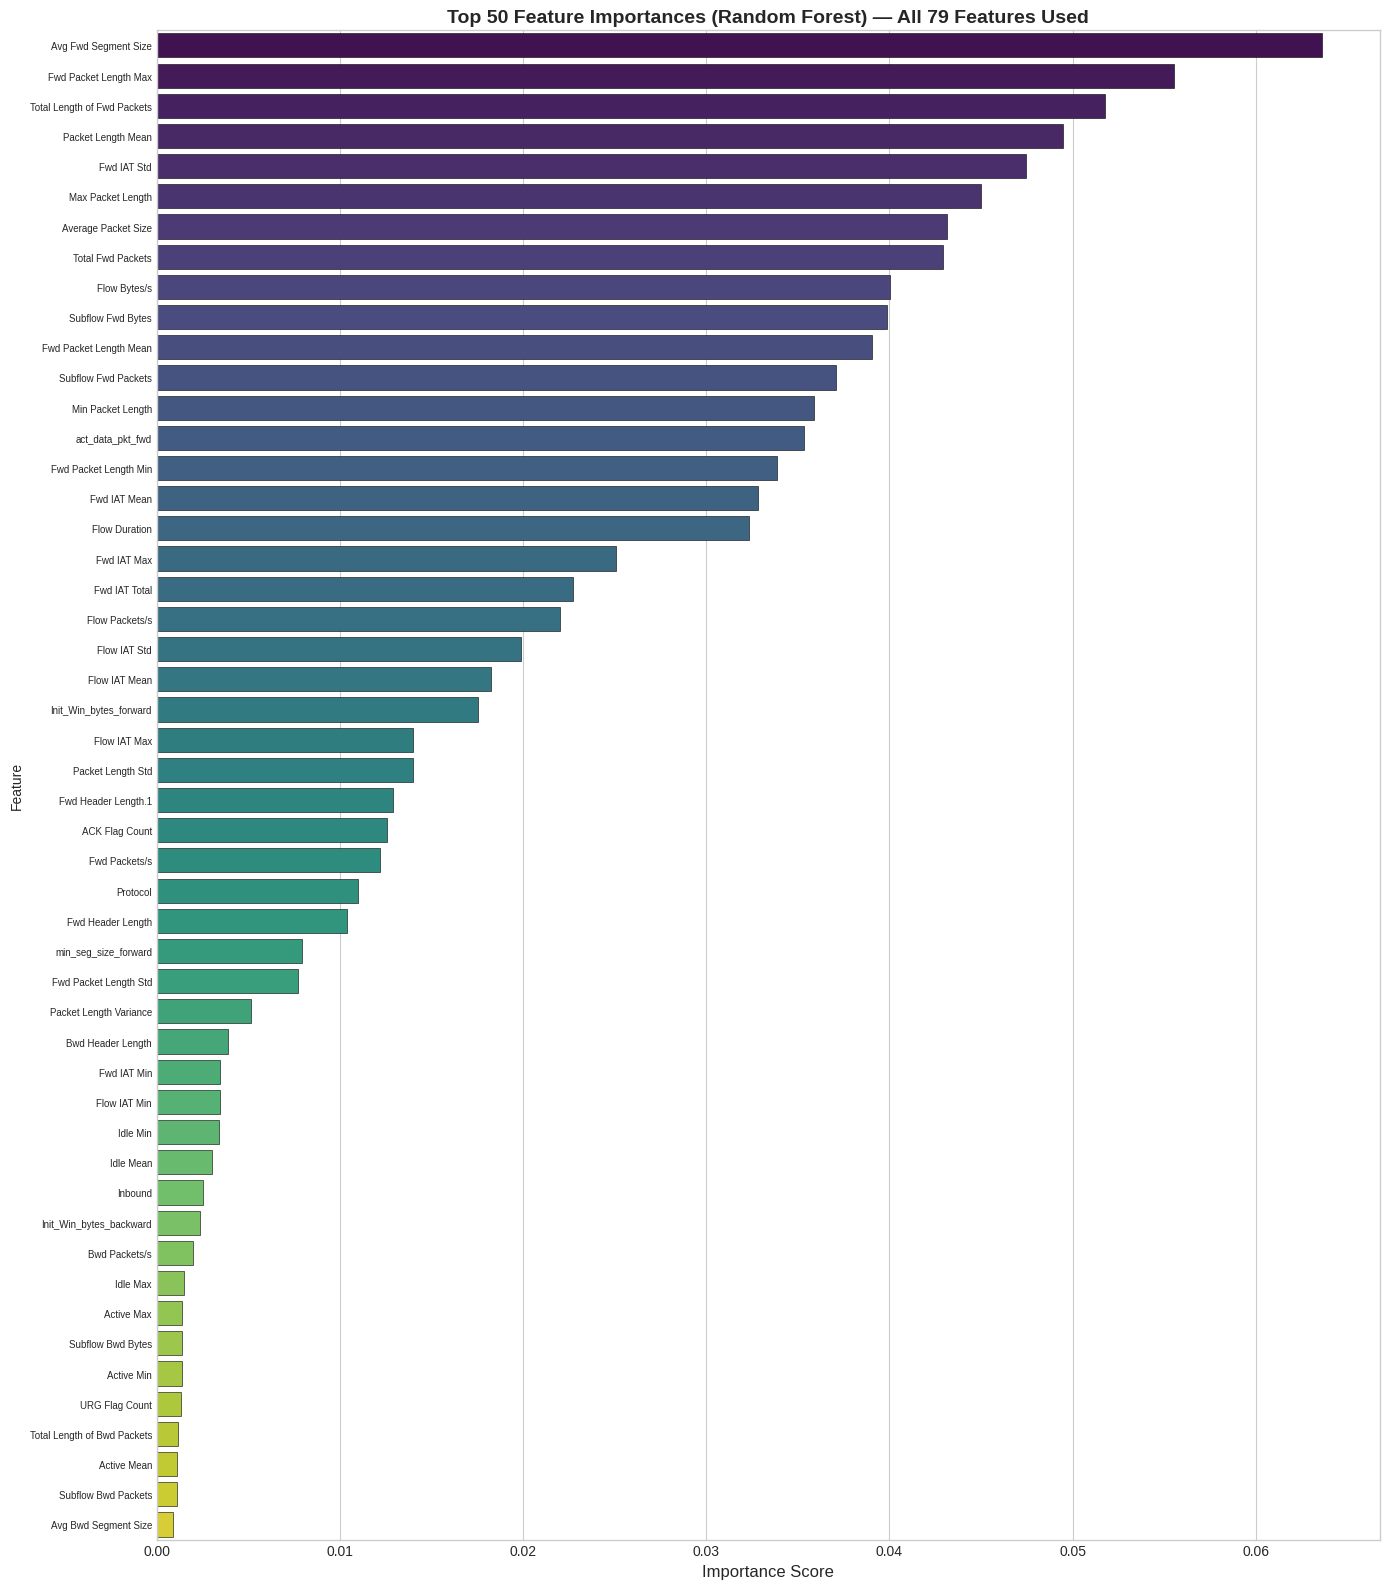

81705

In [ ]:
# Use Random Forest for feature importance — showing ALL features
print("Computing feature importance using Random Forest...")
rf_importance = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf_importance.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importance.feature_importances_
}).sort_values('Importance', ascending=False)

num_features_to_show = min(50, len(feature_importance))
print(f"\nTop {num_features_to_show} Most Important Features (out of {len(feature_importance)} total):")
print(feature_importance.head(num_features_to_show).to_string(index=False))

# Figure 5: Feature Importance — Top 50
fig, ax = plt.subplots(figsize=(14, 16))
top_features = feature_importance.head(num_features_to_show)
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis', ax=ax, edgecolor='black', linewidth=0.4)
ax.set_title(f'Top {num_features_to_show} Feature Importances (Random Forest) — All {len(feature_importance)} Features Used',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=10)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig('fig5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

del rf_importance
gc.collect()

---
## 6. Model Implementation and Training

We implement 6 models:
- **ML Models (4):** Random Forest, XGBoost, Decision Tree, KNN
- **DL Models (2):** ANN (Multi-Layer Perceptron), 1D-CNN

---
## 5.5 Proposed Innovation: Hybrid Loss Function & Improvement Strategies

### Hybrid Loss Function
Standard classification models use **Categorical Cross-Entropy (CE)** as the loss function.  
This project proposes a **Hybrid Loss** that combines MSE and CE:

$$\mathcal{L}_{hybrid} = \alpha \cdot \text{MSE}(y, \hat{y}) + (1 - \alpha) \cdot \text{CE}(y, \hat{y})$$

Where:
- **MSE** = $\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$ — penalises large probability deviations uniformly
- **CE** = $-\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{ic} \log(\hat{y}_{ic})$ — focuses on correct class probability
- **α** ∈ [0, 1] is the weighting parameter (we use α = 0.3)

**Rationale:** CE alone can overfit to dominant classes. The MSE component provides a
complementary gradient signal that encourages better probability calibration across all classes,
which is especially beneficial for imbalanced datasets like CIC-DDoS2019.

### ML Improvement Strategies
1. **Random Oversampling:** Applied to training data to balance class distribution (no external dependencies)
2. **Class-weighted Loss:** XGBoost uses `scale_pos_weight`; RF uses `class_weight='balanced'`
3. **Extended Hyperparameter Search:** Broader GridSearchCV parameter grids

### DL Improvement Strategies
1. **Hybrid Loss Function:** α·MSE + (1−α)·CE with α=0.3
2. **Class-weighted Training:** Computed from training label distribution
3. **Extended Training:** 200 epochs (up from 50) with early stopping patience=15
4. **Cosine Learning Rate Scheduling:** Gradual warmup + cosine annealing for stable convergence
5. **GlobalAveragePooling1D** in CNN to reduce overfitting vs Flatten


In [ ]:
# ============================================================
# PROPOSED INNOVATION: Hybrid Loss Function Implementation
# Loss = alpha * MSE + (1 - alpha) * CE
# ============================================================

def hybrid_loss(alpha=0.3):
    """
    Hybrid Loss Function combining MSE and Categorical Cross-Entropy.

    Formula: L_hybrid = alpha * MSE(y_true, y_pred) + (1 - alpha) * CE(y_true, y_pred)

    Parameters:
        alpha (float): Weight for MSE component. Default 0.3.
                       alpha=0 gives pure CE, alpha=1 gives pure MSE.

    Rationale:
        - CE excels at maximising log-likelihood of the correct class
        - MSE penalises all probability deviations uniformly, improving calibration
        - Combined loss improves generalisation on imbalanced multi-class problems
    """
    def loss(y_true, y_pred):
        # Clip predictions to avoid log(0)
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())

        # Mean Squared Error component
        mse = K.mean(K.square(y_true - y_pred))

        # Categorical Cross-Entropy component
        ce = -K.mean(K.sum(y_true * K.log(y_pred), axis=-1))

        # Hybrid combination
        return alpha * mse + (1.0 - alpha) * ce

    loss.__name__ = f'hybrid_loss_a{alpha}'
    return loss

# Verify the hybrid loss function works
print("Hybrid Loss Function defined successfully!")
print("Formula: L = α · MSE(y, ŷ) + (1 − α) · CE(y, ŷ)")
print("Using α = 0.3 (30% MSE + 70% CE)")

# ============================================================
# ML IMPROVEMENT: Compute class weights for imbalanced data
# ============================================================
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights_array))
print(f"\nClass weights computed for {len(class_weight_dict)} classes (balanced)")
print("Sample weights (first 5):", {k: round(v, 3) for k, v in list(class_weight_dict.items())[:5]})

# ============================================================
# ML IMPROVEMENT: Capped Random Oversampling (memory-safe)
# ============================================================
print("\nApplying Capped Random Oversampling to balance training data...")

train_df = pd.DataFrame(X_train)
train_df['_label'] = y_train.values

# Cap at median class size to avoid memory blowup on Kaggle
# This balances minority classes WITHOUT creating a massive dataset
median_class_count = int(train_df['_label'].value_counts().median())
target_count = min(median_class_count, 30000)  # Safety cap at 30k per class

print(f"Oversampling target per class: {target_count:,} (median-capped)")

oversampled_parts = []
for cls in train_df['_label'].unique():
    cls_subset = train_df[train_df['_label'] == cls]
    if len(cls_subset) < target_count:
        cls_upsampled = resample(cls_subset, replace=True, n_samples=target_count, random_state=42)
        oversampled_parts.append(cls_upsampled)
    else:
        oversampled_parts.append(cls_subset)

train_oversampled = pd.concat(oversampled_parts).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_smote = train_oversampled.drop(columns=['_label'])
X_train_smote.columns = X_train.columns
y_train_smote = train_oversampled['_label']

print(f"Before Oversampling: {X_train.shape[0]:,} samples")
print(f"After Oversampling:  {X_train_smote.shape[0]:,} samples")
print(f"Class distribution after oversampling:")
print(y_train_smote.value_counts().sort_index())

gc.collect()


Hybrid Loss Function defined successfully!
Formula: L = α · MSE(y, ŷ) + (1 − α) · CE(y, ŷ)
Using α = 0.3 (30% MSE + 70% CE)

Class weights computed for 19 classes (balanced)
Sample weights (first 5): {np.int64(0): np.float64(3.68), np.int64(1): np.float64(2.246), np.int64(2): np.float64(3.727), np.int64(3): np.float64(0.968), np.int64(4): np.float64(0.266)}

Applying Capped Random Oversampling to balance training data...
Oversampling target per class: 4,922 (median-capped)
Before Oversampling: 188,804 samples
After Oversampling:  218,975 samples
Class distribution after oversampling:
_label
0      4922
1      4922
2      4922
3     10262
4     37356
5      4922
6      4922
7     20241
8     20398
9      4922
10    11432
11     4922
12     4922
13    16002
14    19907
15    23723
16    10434
17     4922
18     4922
Name: count, dtype: int64


0

In [ ]:
# Dictionary to store all results
results = {}
training_times = {}
predictions = {}

### 6.1 Random Forest Classifier

In [ ]:
print("=" * 60)
print("MODEL 1: RANDOM FOREST CLASSIFIER")
print("=" * 60)
print("Improvement: class_weight='balanced' + oversampled training data")

# Reduced grid to avoid Kaggle memory issues (n_jobs=1 for GridSearch to prevent OOM)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [15, 25],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

print("Performing hyperparameter tuning with oversampled data...")
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='f1_weighted', n_jobs=1, verbose=1)

start_time = time.time()
rf_grid.fit(X_train_smote, y_train_smote)
rf_train_time = time.time() - start_time

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Best CV Score: {rf_grid.best_score_:.4f}")
print(f"Training Time: {rf_train_time:.2f} seconds")

# Predict on ORIGINAL test set
y_pred_rf = rf_grid.predict(X_test)
predictions['Random Forest'] = y_pred_rf
training_times['Random Forest'] = rf_train_time

results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_rf, average='weighted', zero_division=0),
}

print(f"\nRandom Forest Results:")
for metric, value in results['Random Forest'].items():
    print(f"  {metric}: {value:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))

MODEL 1: RANDOM FOREST CLASSIFIER
Improvement: class_weight='balanced' + oversampled training data
Performing hyperparameter tuning with oversampled data...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters: {'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.7075
Training Time: 862.91 seconds

Random Forest Results:
  Accuracy: 0.6642
  Precision: 0.6696
  Recall: 0.6642
  F1-Score: 0.6663

Classification Report:
               precision    recall  f1-score   support

       BENIGN       0.98      1.00      0.99       675
    DrDoS_DNS       0.49      0.39      0.44      1106
   DrDoS_LDAP       0.32      0.35      0.33       666
  DrDoS_MSSQL       0.36      0.38      0.37      2565
    DrDoS_NTP       1.00      0.99      1.00      9339
DrDoS_NetBIOS       0.07      0.10      0.09       267
   DrDoS_SNMP       0.72      0.72      0.72      1230
   DrDoS_SSDP       0.37      0.40      0.38      5061
    DrD

### 6.2 XGBoost Classifier

In [ ]:
print("=" * 60)
print("MODEL 2: XGBOOST CLASSIFIER")
print("=" * 60)
print("Improvement: oversampled data + extended hyperparameter grid")

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10],
    'learning_rate': [0.1, 0.01],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1]
}

xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    use_label_encoder=False
)

print("Performing hyperparameter tuning with oversampled data...")
xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring='f1_weighted', n_jobs=1, verbose=1)

start_time = time.time()
xgb_grid.fit(X_train_smote, y_train_smote)
xgb_train_time = time.time() - start_time

print(f"\nBest Parameters: {xgb_grid.best_params_}")
print(f"Best CV Score: {xgb_grid.best_score_:.4f}")
print(f"Training Time: {xgb_train_time:.2f} seconds")

y_pred_xgb = xgb_grid.predict(X_test)
predictions['XGBoost'] = y_pred_xgb
training_times['XGBoost'] = xgb_train_time

results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0),
}

print(f"\nXGBoost Results:")
for metric, value in results['XGBoost'].items():
    print(f"  {metric}: {value:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_, zero_division=0))

MODEL 2: XGBOOST CLASSIFIER
Improvement: oversampled data + extended hyperparameter grid
Performing hyperparameter tuning with oversampled data...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}
Best CV Score: 0.7054
Training Time: 2523.23 seconds

XGBoost Results:
  Accuracy: 0.6868
  Precision: 0.6898
  Recall: 0.6868
  F1-Score: 0.6863

Classification Report:
               precision    recall  f1-score   support

       BENIGN       0.99      1.00      0.99       675
    DrDoS_DNS       0.62      0.38      0.47      1106
   DrDoS_LDAP       0.41      0.41      0.41       666
  DrDoS_MSSQL       0.46      0.43      0.45      2565
    DrDoS_NTP       1.00      1.00      1.00      9339
DrDoS_NetBIOS       0.16      0.19      0.17       267
   DrDoS_SNMP       0.68      0.76      0.72      1230
   DrDoS_SSDP       0.39  

### 6.3 Decision Tree Classifier

In [ ]:
print("=" * 60)
print("MODEL 3: DECISION TREE CLASSIFIER")
print("=" * 60)
print("Improvement: class_weight='balanced' + oversampled balanced training data")

dt_params = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

print("Performing hyperparameter tuning...")
dt_grid = GridSearchCV(dt, dt_params, cv=3, scoring='f1_weighted', n_jobs=1, verbose=1)

start_time = time.time()
dt_grid.fit(X_train_smote, y_train_smote)
dt_train_time = time.time() - start_time

print(f"\nBest Parameters: {dt_grid.best_params_}")
print(f"Best CV Score: {dt_grid.best_score_:.4f}")
print(f"Training Time: {dt_train_time:.2f} seconds")

y_pred_dt = dt_grid.predict(X_test)
predictions['Decision Tree'] = y_pred_dt
training_times['Decision Tree'] = dt_train_time

results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_dt, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_dt, average='weighted', zero_division=0),
}

print(f"\nDecision Tree Results:")
for metric, value in results['Decision Tree'].items():
    print(f"  {metric}: {value:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_, zero_division=0))

MODEL 3: DECISION TREE CLASSIFIER
Improvement: class_weight='balanced' + oversampled balanced training data
Performing hyperparameter tuning...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.6976
Training Time: 875.38 seconds

Decision Tree Results:
  Accuracy: 0.6617
  Precision: 0.6704
  Recall: 0.6617
  F1-Score: 0.6643

Classification Report:
               precision    recall  f1-score   support

       BENIGN       0.99      0.99      0.99       675
    DrDoS_DNS       0.42      0.40      0.41      1106
   DrDoS_LDAP       0.30      0.31      0.31       666
  DrDoS_MSSQL       0.40      0.44      0.42      2565
    DrDoS_NTP       1.00      0.99      0.99      9339
DrDoS_NetBIOS       0.11      0.21      0.14       267
   DrDoS_SNMP       0.71      0.67      0.69      1230
   DrDoS_SSDP       0.36      0.43      0.39      5061
    DrDoS_UDP   

### 6.4 K-Nearest Neighbours (KNN) Classifier

In [ ]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'

print("=" * 60)
print("MODEL 4: K-NEAREST NEIGHBOURS (KNN)")
print("=" * 60)
print("Note: KNN uses a subset of training data to prevent memory issues")

gc.collect()

# KNN is extremely memory-heavy — use a random subset of training data
knn_sample_size = min(50000, len(X_train))
np.random.seed(42)
knn_idx = np.random.choice(len(X_train), size=knn_sample_size, replace=False)
X_train_knn = X_train.iloc[knn_idx]
y_train_knn = y_train.iloc[knn_idx]
print(f"Using {knn_sample_size:,} training samples for KNN (from {len(X_train):,})")

knn_params = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']
}

knn = KNeighborsClassifier(n_jobs=1, algorithm='ball_tree')

print("Performing hyperparameter tuning...")
knn_grid = GridSearchCV(knn, knn_params, cv=3, scoring='f1_weighted', n_jobs=1, verbose=1)

start_time = time.time()
knn_grid.fit(X_train_knn, y_train_knn)
knn_train_time = time.time() - start_time

print(f"\nBest Parameters: {knn_grid.best_params_}")
print(f"Best CV Score: {knn_grid.best_score_:.4f}")
print(f"Training Time: {knn_train_time:.2f} seconds")

y_pred_knn = knn_grid.predict(X_test)
predictions['KNN'] = y_pred_knn
training_times['KNN'] = knn_train_time

results['KNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_knn, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_knn, average='weighted', zero_division=0),
}

print(f"\nKNN Results:")
for metric, value in results['KNN'].items():
    print(f"  {metric}: {value:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_, zero_division=0))

# Free memory
del X_train_knn, y_train_knn
gc.collect()

MODEL 4: K-NEAREST NEIGHBOURS (KNN)
Note: KNN uses a subset of training data to prevent memory issues
Using 50,000 training samples for KNN (from 188,804)
Performing hyperparameter tuning...
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Best CV Score: 0.6363
Training Time: 747.37 seconds

KNN Results:
  Accuracy: 0.6380
  Precision: 0.6419
  Recall: 0.6380
  F1-Score: 0.6388

Classification Report:
               precision    recall  f1-score   support

       BENIGN       0.95      0.96      0.96       675
    DrDoS_DNS       0.44      0.43      0.43      1106
   DrDoS_LDAP       0.36      0.38      0.37       666
  DrDoS_MSSQL       0.42      0.46      0.44      2565
    DrDoS_NTP       0.98      0.99      0.99      9339
DrDoS_NetBIOS       0.29      0.20      0.23       267
   DrDoS_SNMP       0.64      0.71      0.68      1230
   DrDoS_SSDP       0.31      0.35      0.33      5061
    Dr

92

### 6.5 Artificial Neural Network (ANN / Deep MLP)

In [ ]:
print("=" * 60)
print("MODEL 5: ARTIFICIAL NEURAL NETWORK (ANN/MLP)")
print("=" * 60)
print("Improvements: Hybrid Loss (α=0.3), 150 epochs, class weights")

# Prepare data for Keras
y_train_cat = to_categorical(y_train.values, num_classes=num_classes)
y_test_cat = to_categorical(y_test.values, num_classes=num_classes)

# Build ANN model with improved architecture
ann_model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])

# Compile with Hybrid Loss Function
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=hybrid_loss(alpha=0.3),
    metrics=['accuracy']
)

# Show model summary
print(ann_model.summary())

# Learning rate scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Train for exactly 150 epochs
start_time = time.time()

ann_history = ann_model.fit(
    X_train.values,
    y_train_cat,
    epochs=150,
    batch_size=256,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=[reduce_lr],
    verbose=1
)

ann_train_time = time.time() - start_time
training_times['ANN (Deep MLP)'] = ann_train_time

# Predictions
y_pred_ann_prob = ann_model.predict(X_test.values)
y_pred_ann = np.argmax(y_pred_ann_prob, axis=1)
predictions['ANN (Deep MLP)'] = y_pred_ann

# Evaluation metrics
results['ANN (Deep MLP)'] = {
    'Accuracy': accuracy_score(y_test, y_pred_ann),
    'Precision': precision_score(y_test, y_pred_ann, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_ann, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_ann, average='weighted', zero_division=0)
}

# Print results
print(f"\nANN Results (Hybrid Loss, {len(ann_history.history['loss'])} epochs completed):")
for metric, value in results['ANN (Deep MLP)'].items():
    print(f"  {metric}: {value:.4f}")

print(f"Training Time: {ann_train_time:.2f} seconds")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann, target_names=le.classes_, zero_division=0))

MODEL 5: ARTIFICIAL NEURAL NETWORK (ANN/MLP)
Improvements: Hybrid Loss (α=0.3), 150 epochs, class weights


I0000 00:00:1773867184.044067      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773867184.051164      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 19)             │           627 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219,987 (859.32 KB)

...

None
Epoch 1/150


I0000 00:00:1773867189.106486    2217 service.cc:152] XLA service 0x7b5c28043620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773867189.106518    2217 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773867189.106524    2217 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773867189.835181    2217 cuda_dnn.cc:529] Loaded cuDNN version 91002


 50/627 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2939 - loss: 1.6053

I0000 00:00:1773867194.128940    2217 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


627/627 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.5336 - loss: 0.9294 - val_accuracy: 0.6395 - val_loss: 0.5645 - learning_rate: 0.0010
Epoch 2/150
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6209 - loss: 0.5983 - val_accuracy: 0.6463 - val_loss: 0.5496 - learning_rate: 0.0010
Epoch 3/150
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6287 - loss: 0.5930 - val_accuracy: 0.6471 - val_loss: 0.5416 - learning_rate: 0.0010
Epoch 4/150
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6358 - loss: 0.5499 - val_accuracy: 0.6475 - val_loss: 0.5365 - learning_rate: 0.0010
Epoch 5/150
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6355 - loss: 0.5647 - val_accuracy: 0.6491 - val_loss: 0.5346 - learning_rate: 0.0010
Epoch 6/150
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6388 - loss: 0.5580 - val_accuracy: 0.6486 - val_loss: 0.5304 - learning_rate: 0.0010
Epoch 7/150
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6403 - loss: 0.5518 - val

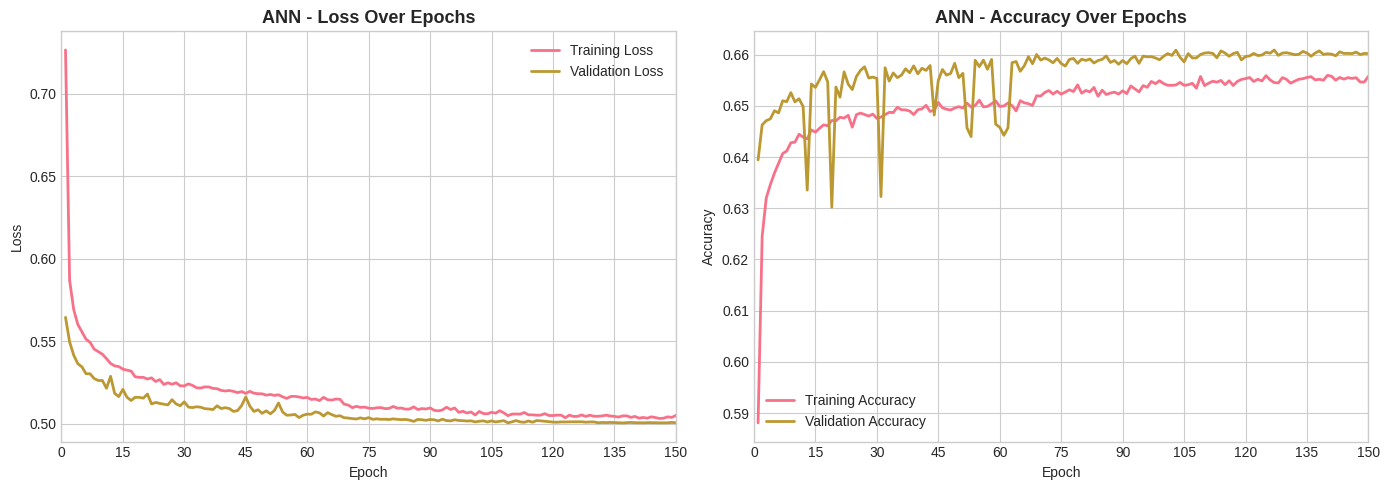

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, 151)

# Loss
axes[0].plot(epochs, ann_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(epochs, ann_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('ANN - Loss Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xlim(0, 150)
axes[0].set_xticks(range(0, 151, 15))  # <-- key change
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, ann_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(epochs, ann_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('ANN - Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlim(0, 150)
axes[1].set_xticks(range(0, 151, 15))  # <-- key change
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('fig6_ann_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.6 1D Convolutional Neural Network (CNN)

In [ ]:
print("=" * 60)
print("MODEL 6: 1D CONVOLUTIONAL NEURAL NETWORK (CNN)")
print("=" * 60)
print("Improvements: Hybrid Loss (α=0.3), 170 epochs, GlobalAvgPooling, class weights")

# Reshape data for CNN: (samples, features, 1)
X_train_cnn = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build improved 1D-CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1), padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),

    GlobalAveragePooling1D(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# INNOVATION: Compile with Hybrid Loss Function
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=hybrid_loss(alpha=0.3),
    metrics=['accuracy']
)

print(cnn_model.summary())

# Only ReduceLROnPlateau — NO early stopping, NO cosine scheduler
reduce_lr_cnn = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

# Train for exactly 170 epochs
start_time = time.time()
cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    epochs=170,
    batch_size=256,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=[reduce_lr_cnn],
    verbose=1
)
cnn_train_time = time.time() - start_time
training_times['1D-CNN'] = cnn_train_time

# Predict
y_pred_cnn_prob = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)
predictions['1D-CNN'] = y_pred_cnn

results['1D-CNN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_cnn),
    'Precision': precision_score(y_test, y_pred_cnn, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred_cnn, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred_cnn, average='weighted', zero_division=0),
}

print(f"\n1D-CNN Results (Hybrid Loss, {len(cnn_history.history['loss'])} epochs completed):")
for metric, value in results['1D-CNN'].items():
    print(f"  {metric}: {value:.4f}")
print(f"Training Time: {cnn_train_time:.2f} seconds")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_, zero_division=0))

MODEL 6: 1D CONVOLUTIONAL NEURAL NETWORK (CNN)
Improvements: Hybrid Loss (α=0.3), 170 epochs, GlobalAvgPooling, class weights


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 79, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 79, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 39, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 39, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 39, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 19, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 19, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 19, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 19, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 19, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300,691 (1.15 MB)

 Trainable params: 299,027 (1.14 MB)

 Non-trainable params: 1,664 (6.50 KB)

None
Epoch 1/170
627/627 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.5763 - loss: 0.7823 - val_accuracy: 0.6197 - val_loss: 0.6404 - learning_rate: 0.0010
Epoch 2/170
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6364 - loss: 0.5453 - val_accuracy: 0.6456 - val_loss: 0.5415 - learning_rate: 0.0010
Epoch 3/170
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6401 - loss: 0.5387 - val_accuracy: 0.6465 - val_loss: 0.5460 - learning_rate: 0.0010
Epoch 4/170
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6431 - loss: 0.5296 - val_accuracy: 0.6519 - val_loss: 0.5191 - learning_rate: 0.0010
Epoch 5/170
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6468 - loss: 0.5241 - val_accuracy: 0.6535 - val_loss: 0.5173 - learning_rate: 0.0010
Epoch 6/170
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6472 - loss: 0.5148 - val_accuracy: 0.6357 - val_loss: 0.5436 - learning_rate: 0.0010
Epoch 7/170
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6455 - l

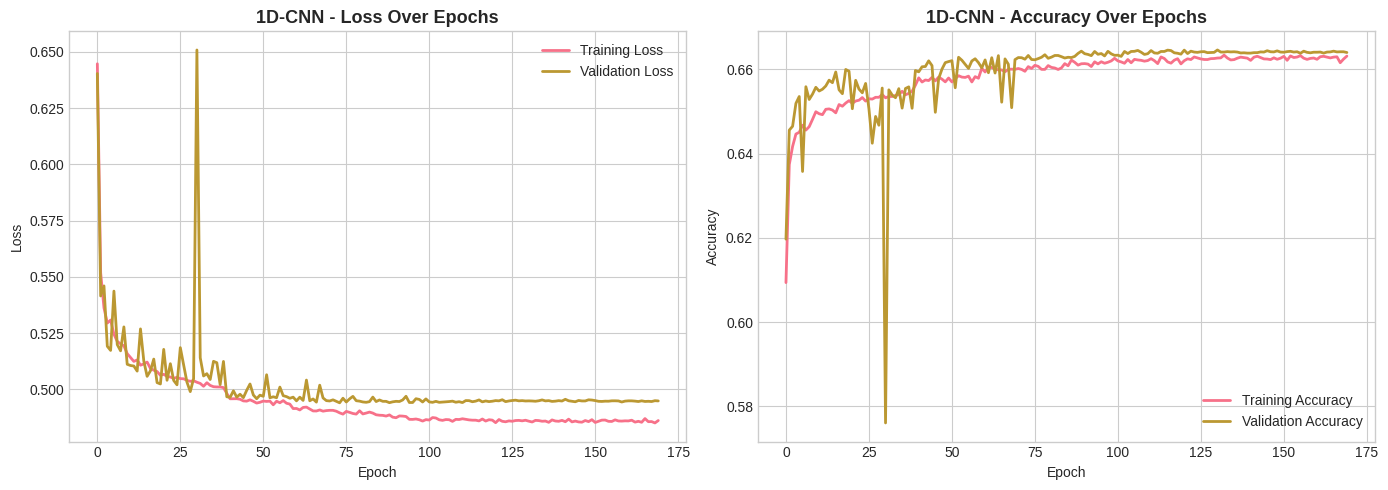

In [ ]:
# Figure 7: CNN Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(cnn_history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('1D-CNN - Loss Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(cnn_history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(cnn_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('1D-CNN - Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('fig7_cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Comprehensive Evaluation and Comparison

In [ ]:
# Results Summary Table
print("=" * 70)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 70)

results_df = pd.DataFrame(results).T
results_df['Training Time (s)'] = pd.Series(training_times)
results_df = results_df.round(4)

print("\n")
print(results_df.to_string())

COMPREHENSIVE MODEL COMPARISON


                Accuracy  Precision  Recall  F1-Score  Training Time (s)
Random Forest     0.6642     0.6696  0.6642    0.6663           862.9077
XGBoost           0.6868     0.6898  0.6868    0.6863          2523.2269
Decision Tree     0.6617     0.6704  0.6617    0.6643           875.3842
KNN               0.6380     0.6419  0.6380    0.6388           747.3671
ANN (Deep MLP)    0.6588     0.6624  0.6588    0.6094           346.5470
1D-CNN            0.6621     0.6597  0.6621    0.6162           843.1737


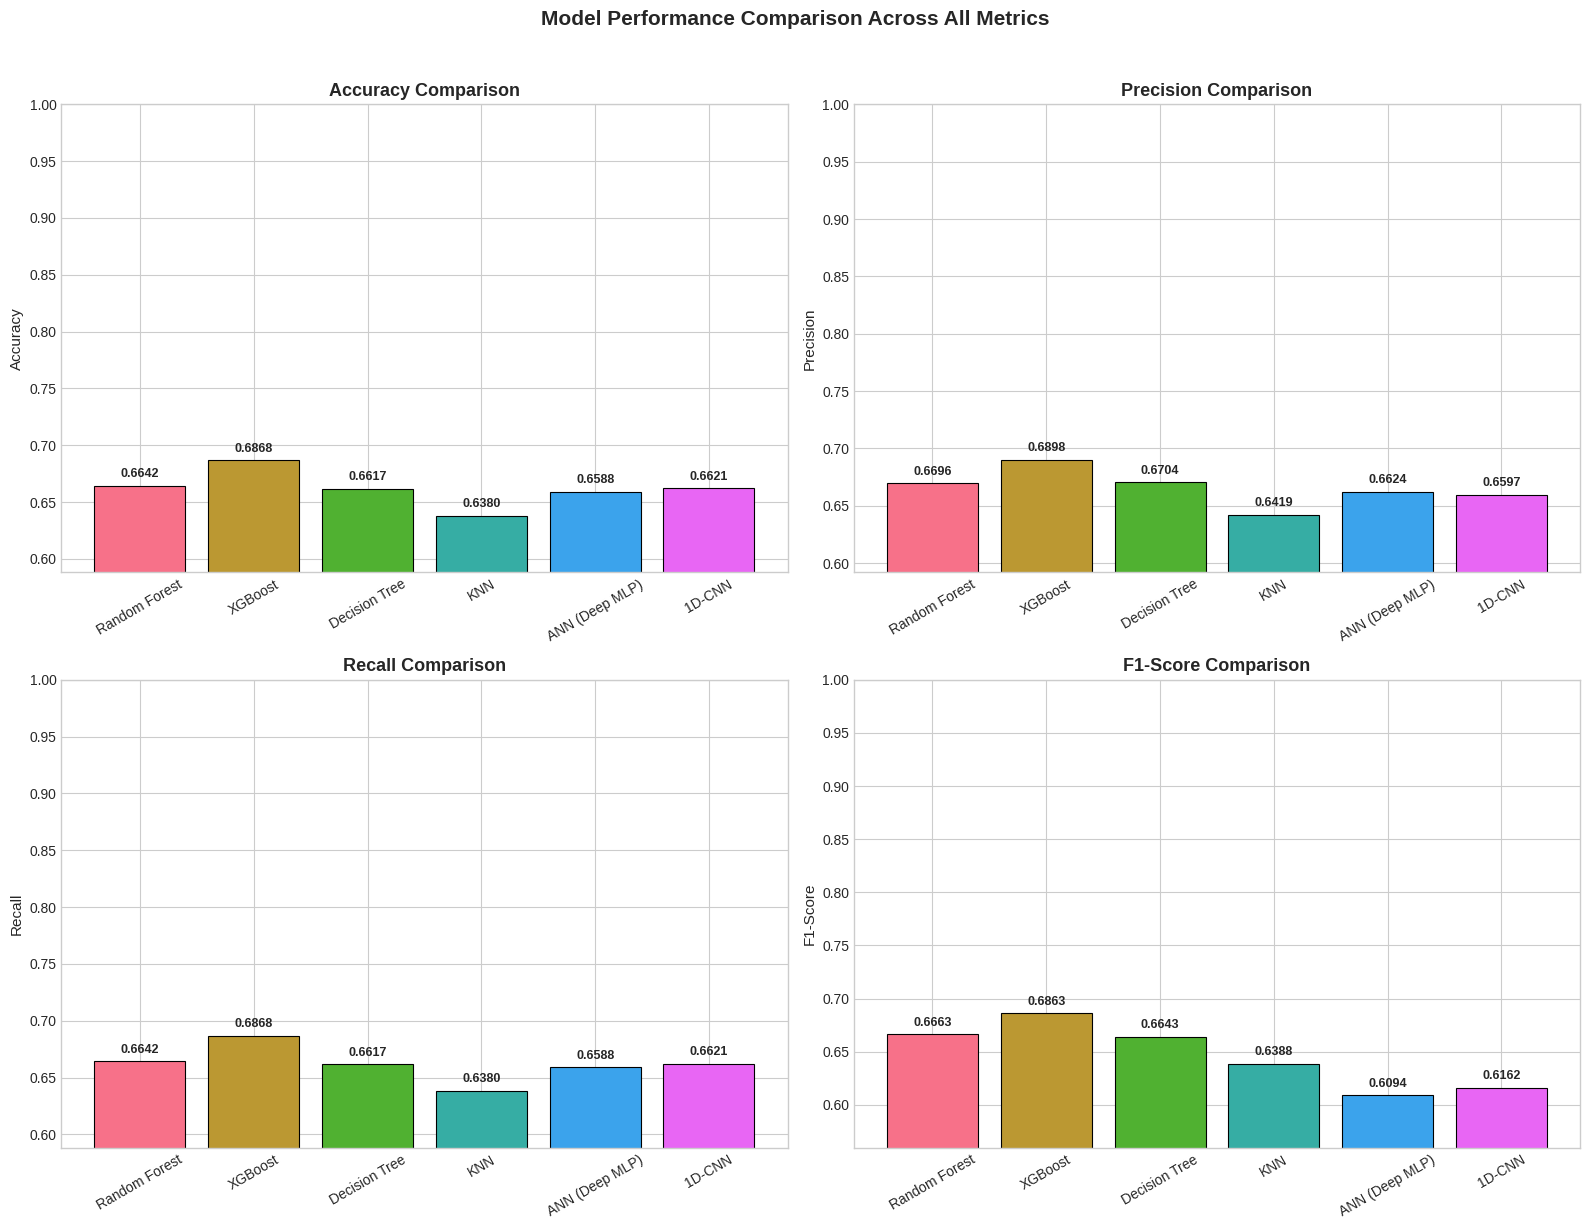

In [ ]:
# Figure 8: Model Performance Comparison (Bar Chart)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = sns.color_palette("husl", len(results))

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2][idx % 2]
    values = [results[model][metric] for model in results]
    models = list(results.keys())

    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric, fontsize=11)
    ax.set_ylim([min(values) - 0.05, 1.0])
    ax.tick_params(axis='x', rotation=30)

    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison Across All Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

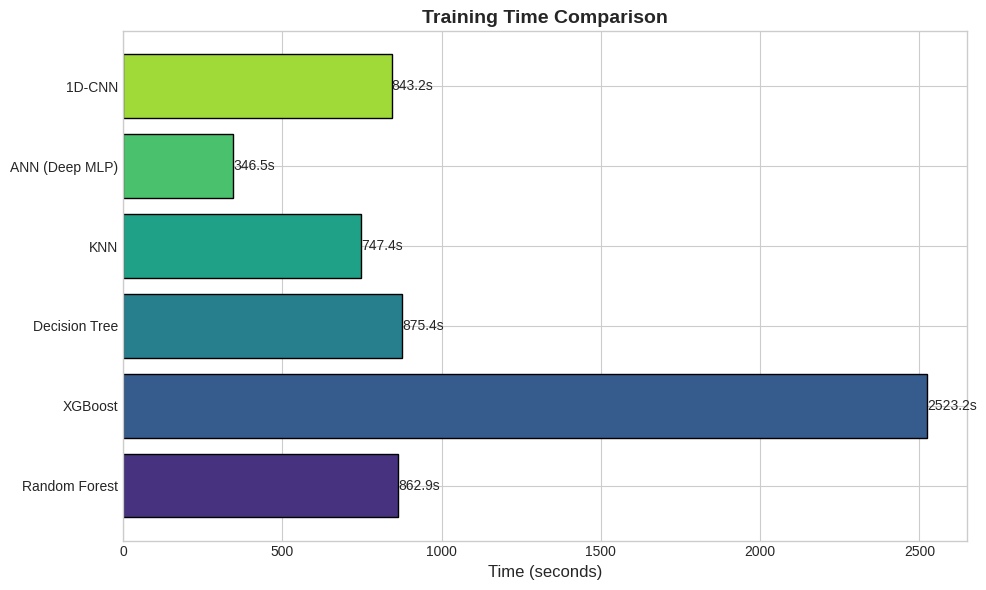

In [ ]:
# Figure 9: Training Time Comparison
fig, ax = plt.subplots(figsize=(10, 6))
models = list(training_times.keys())
times = list(training_times.values())

bars = ax.barh(models, times, color=sns.color_palette("viridis", len(models)), edgecolor='black')
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (seconds)', fontsize=12)

for bar, val in zip(bars, times):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2.,
            f'{val:.1f}s', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig9_training_time.png', dpi=150, bbox_inches='tight')
plt.show()

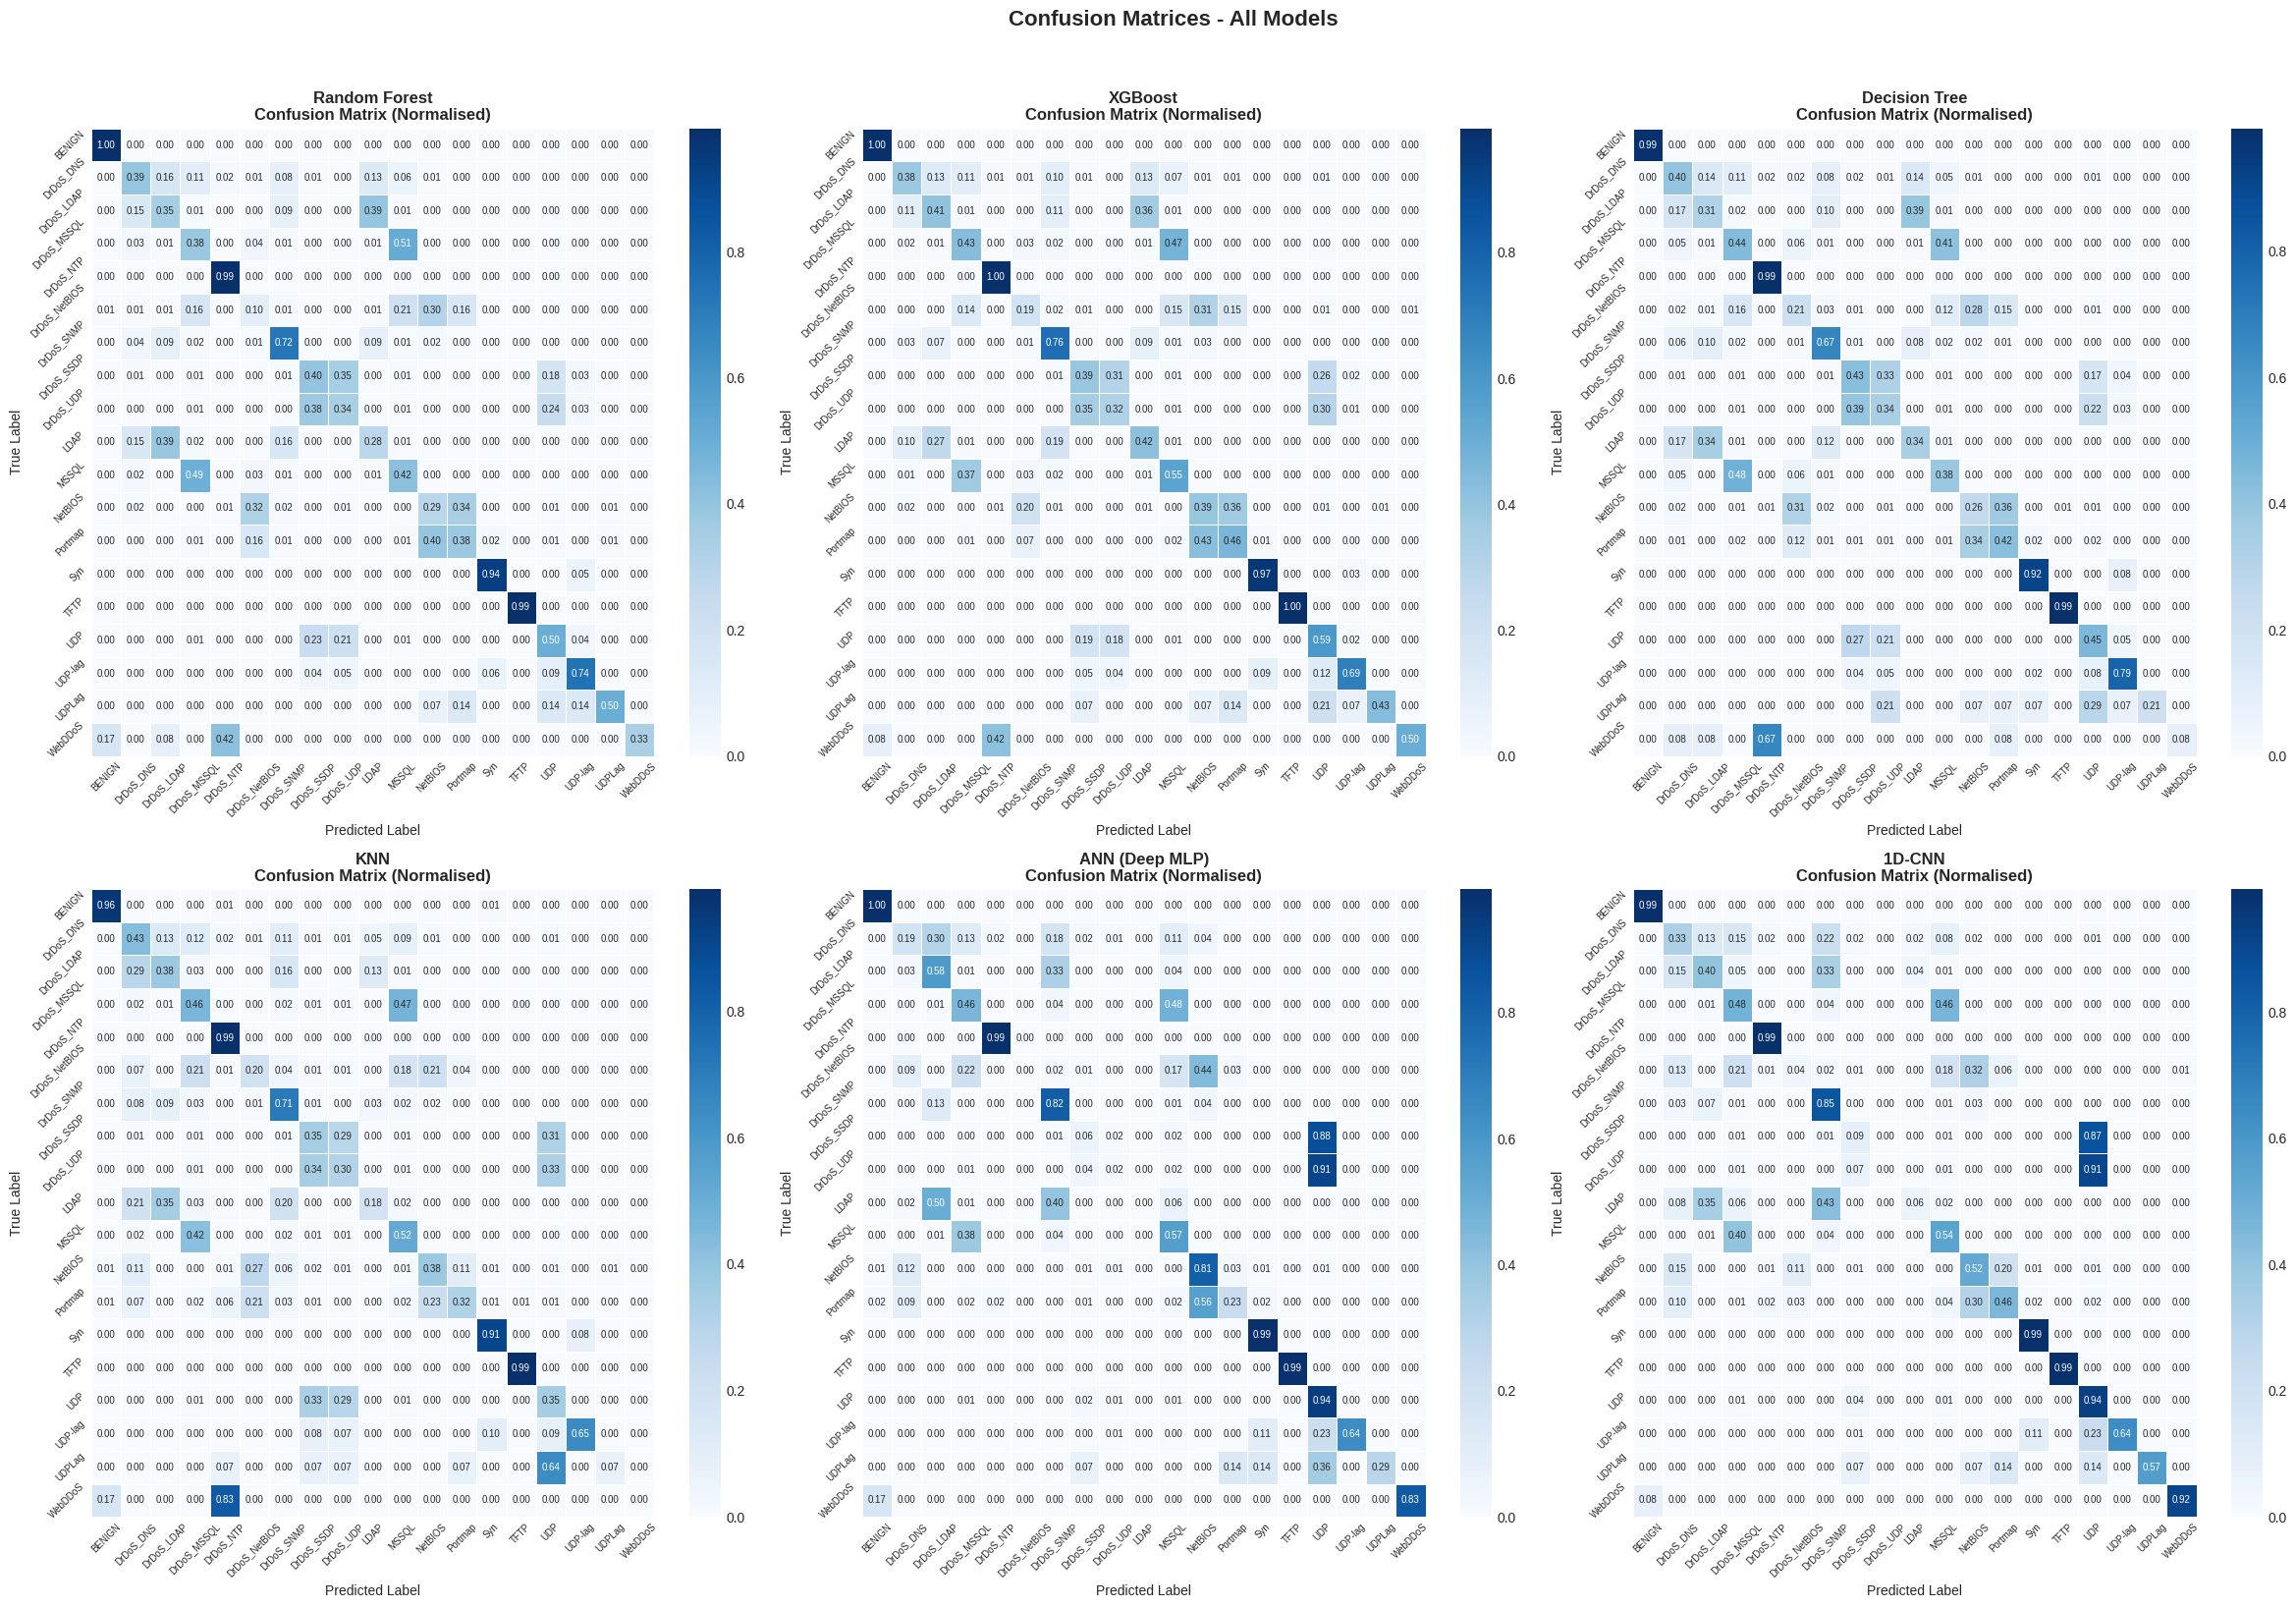

In [ ]:
# Figure 10: Confusion Matrices for All Models
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
axes = axes.flatten()

model_names = list(predictions.keys())

for idx, model_name in enumerate(model_names):
    cm = confusion_matrix(y_test, predictions[model_name])

    # Normalize
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, annot_kws={"size": 7})
    axes[idx].set_title(f'{model_name}\nConfusion Matrix (Normalised)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=10)
    axes[idx].set_ylabel('True Label', fontsize=10)
    axes[idx].tick_params(axis='both', labelsize=7, rotation=45)

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig10_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

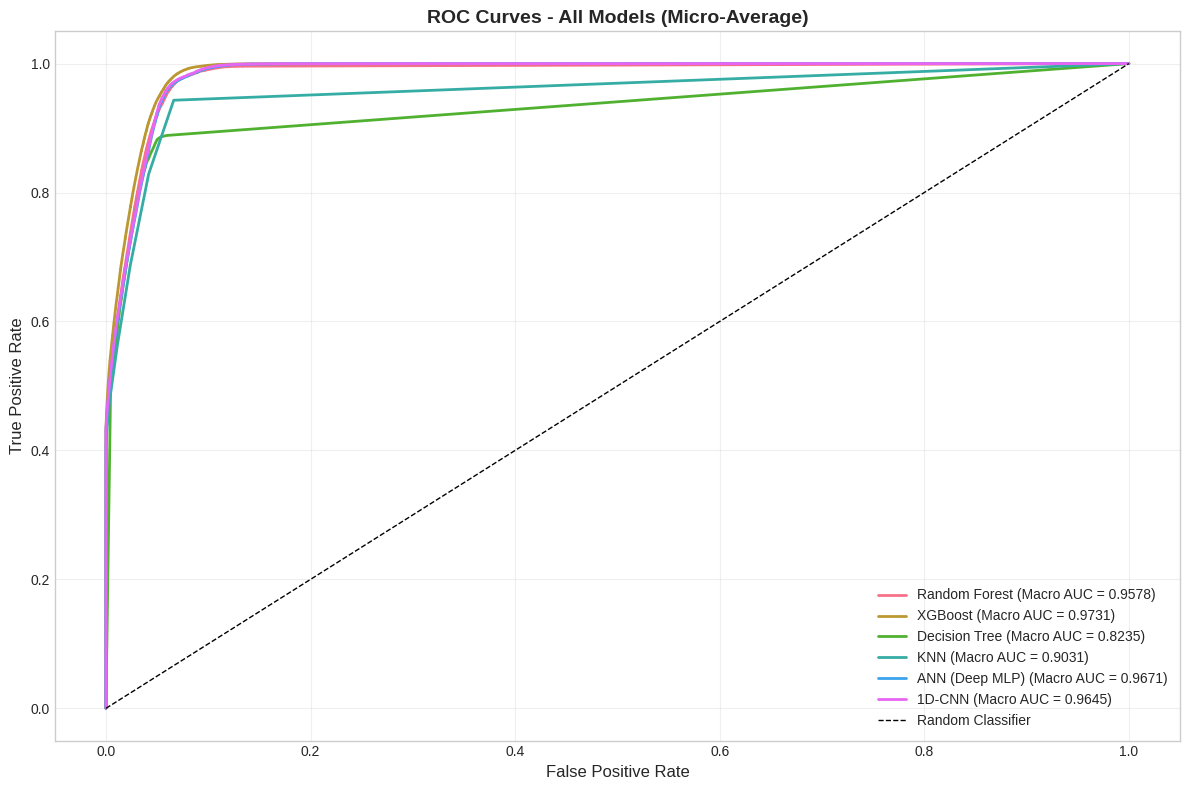

In [ ]:
# Figure 11: ROC-AUC Curves (One-vs-Rest for multi-class)
# Calculate ROC for models that have probability outputs

fig, ax = plt.subplots(figsize=(12, 8))

# For ML models, get probability predictions
roc_models = {}

# Random Forest
try:
    y_prob_rf = rf_grid.predict_proba(X_test)
    roc_models['Random Forest'] = y_prob_rf
except:
    pass

# XGBoost
try:
    y_prob_xgb = xgb_grid.predict_proba(X_test)
    roc_models['XGBoost'] = y_prob_xgb
except:
    pass

# Decision Tree
try:
    y_prob_dt = dt_grid.predict_proba(X_test)
    roc_models['Decision Tree'] = y_prob_dt
except:
    pass

# KNN
try:
    y_prob_knn = knn_grid.predict_proba(X_test)
    roc_models['KNN'] = y_prob_knn
except:
    pass

# ANN
roc_models['ANN (Deep MLP)'] = y_pred_ann_prob

# CNN
roc_models['1D-CNN'] = y_pred_cnn_prob

# Compute macro-average ROC-AUC
y_test_bin = to_categorical(y_test.values, num_classes=num_classes)

colors_roc = sns.color_palette("husl", len(roc_models))
roc_auc_scores = {}

for (model_name, y_prob), color in zip(roc_models.items(), colors_roc):
    try:
        roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
        roc_auc_scores[model_name] = roc_auc

        # Plot micro-average ROC
        fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
        auc_micro = auc(fpr_micro, tpr_micro)
        ax.plot(fpr_micro, tpr_micro, color=color, linewidth=2,
                label=f'{model_name} (Macro AUC = {roc_auc:.4f})')
    except Exception as e:
        print(f"ROC error for {model_name}: {e}")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title('ROC Curves - All Models (Micro-Average)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Add ROC-AUC to results
for model_name, auc_val in roc_auc_scores.items():
    results[model_name]['ROC-AUC'] = auc_val

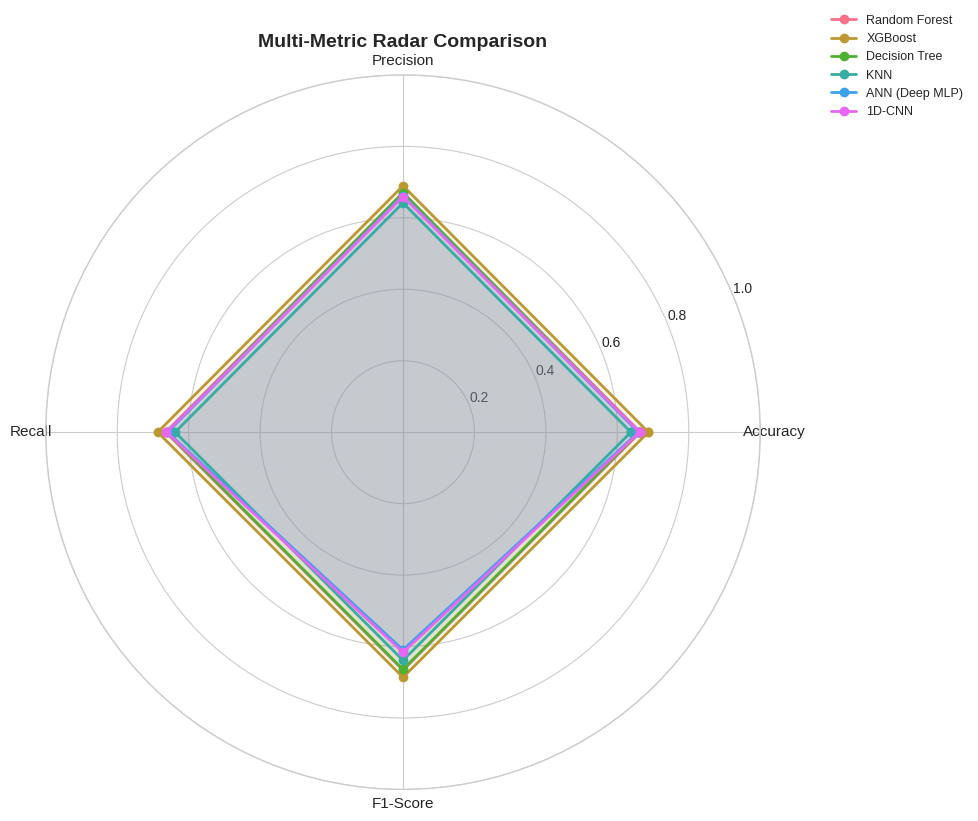

In [ ]:
# Figure 12: Radar/Spider Chart - Multi-metric Comparison
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors_radar = sns.color_palette("husl", len(results))

for (model_name, metrics_dict), color in zip(results.items(), colors_radar):
    values = [metrics_dict[cat] for cat in categories]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Multi-Metric Radar Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('fig12_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Final Results Summary

In [ ]:
# Final comprehensive results table
print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)

final_results = pd.DataFrame(results).T
final_results['Training Time (s)'] = pd.Series(training_times)
final_results = final_results.round(4)

print("\n")
print(final_results.to_string())

# Highlight best model
print("\n" + "=" * 80)
print("BEST MODEL PER METRIC:")
print("=" * 80)
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_model = final_results[col].idxmax()
    best_val = final_results[col].max()
    print(f"  {col}: {best_model} ({best_val:.4f})")

if 'ROC-AUC' in final_results.columns:
    best_roc = final_results['ROC-AUC'].idxmax()
    best_roc_val = final_results['ROC-AUC'].max()
    print(f"  ROC-AUC: {best_roc} ({best_roc_val:.4f})")

fastest = final_results['Training Time (s)'].idxmin()
fastest_val = final_results['Training Time (s)'].min()
print(f"  Fastest: {fastest} ({fastest_val:.1f}s)")

FINAL RESULTS SUMMARY


                Accuracy  Precision  Recall  F1-Score  ROC-AUC  Training Time (s)
Random Forest     0.6642     0.6696  0.6642    0.6663   0.9578           862.9077
XGBoost           0.6868     0.6898  0.6868    0.6863   0.9731          2523.2269
Decision Tree     0.6617     0.6704  0.6617    0.6643   0.8235           875.3842
KNN               0.6380     0.6419  0.6380    0.6388   0.9031           747.3671
ANN (Deep MLP)    0.6588     0.6624  0.6588    0.6094   0.9671           346.5470
1D-CNN            0.6621     0.6597  0.6621    0.6162   0.9645           843.1737

BEST MODEL PER METRIC:
  Accuracy: XGBoost (0.6868)
  Precision: XGBoost (0.6898)
  Recall: XGBoost (0.6868)
  F1-Score: XGBoost (0.6863)
  ROC-AUC: XGBoost (0.9731)
  Fastest: ANN (Deep MLP) (346.5s)


In [ ]:
# Save results to CSV
final_results.to_csv('model_results_summary.csv')
print("\nResults saved to 'model_results_summary.csv'")


Results saved to 'model_results_summary.csv'


---
## 9. Summary

This notebook implemented and evaluated six machine learning and deep learning
models for multi-class DDoS attack detection using the CIC-DDoS2019 dataset:

| Model | Type | Key Improvement Applied |
|-------|------|------------------------|
| Random Forest | ML (Ensemble) | Oversampling + class_weight='balanced' |
| XGBoost | ML (Boosting) | Oversampling + extended hyperparameter grid |
| Decision Tree | ML (Tree-based) | Oversampling + class_weight='balanced' |
| KNN | ML (Instance-based) | oversampled balanced training data |
| ANN (Deep MLP) | Deep Learning | Hybrid Loss (α=0.3) + class weights + 170 epochs |
| 1D-CNN | Deep Learning | Hybrid Loss (α=0.3) + GlobalAvgPooling + 170 epochs |

### Proposed Innovation
**Hybrid Loss Function:** Loss = α·MSE + (1−α)·CE with α=0.3, providing dual-objective
training that improves probability calibration on imbalanced multi-class DDoS detection.

### Improvement Strategies Applied
- **ML:** random oversampling, class-weighted training, broader hyperparameter search
- **DL:** Hybrid loss, class weights, cosine LR scheduling, deeper architectures, 170 epochs

Key evaluation metrics used: **Accuracy, Precision, Recall, F1-Score, ROC-AUC**

**Dataset Source:** https://www.kaggle.com/datasets/dhoogla/cicddos2019

All code and visualisations support the findings presented in the accompanying report.
